---
title: "Sieverts-law hydrogen permeation through Pd membranes"
description: "Why the exponent is one half, what it buys you, and when it stops mattering. The permeance Itoh quotes is derived rather than quoted — and the same numbers show his membrane was 18× larger than his duty, which is why his measurement cannot see it."
categories: [sec:H, struct:S3, struct:S5, tier:T0, data:tier2, phase:gas]
date: 2026-08-01
---

# Sieverts-law hydrogen permeation through Pd membranes

**Catalog ID:** `H1.1` · **Structures:** `S3` (1-D steady BVP — the wall), `S5`
(1-D convection with a nonlinear sink — the channel) · **Tier:** T0

Hydrogen crosses a dense palladium wall in a way nothing else does: it
dissociates on the surface, dissolves as *atoms*, diffuses, and recombines on
the far side. Because two atoms come from one molecule, the dissolved
concentration follows the **square root** of the gas pressure, and the flux
follows the difference of two square roots rather than the difference of two
pressures. That single exponent is the whole content of Sieverts' law, and it is
what every palladium membrane model — including the reactor on page
[`H1.4`](../H1.4-itoh-membrane-dehydrogenation/) — is built on.

This page is about the closure, not about a reactor. It does four things:

1. **derives** the permeance that Itoh (1987) prints as a formula, by solving
   the wall as a radial diffusion problem in pymrm, and lands on the value he
   prints — the one number in the source anything here can be checked against;
2. shows what the exponent ½ *does*: it makes a permeator strip its feed
   completely in a **finite** length against a clean permeate, which an exponent
   of 1 never does, and it makes the required driving mole fraction fall as the
   *square* of the membrane's spare capacity;
3. turns that into a criterion for **when permeation is the limiting
   resistance** — and finds Itoh's membrane 18× from being it, which is the
   condition that puts `H1.4`'s reactor on its fast-permeation ceiling and
   leaves the permeance nothing to move;
4. shows what a departure from ½ means, by putting a finite surface step in
   series with the wall and measuring the apparent exponent it produces.

**Nothing on this page is compared with a permeation measurement, because the
source does not print one.** The validation section says exactly what each check
can and cannot fail on, and breaks every one of them on purpose.

## Background

Palladium's selectivity for hydrogen is old news — Itoh calls it "a phenomenon
that has been known for more than 100 years" — and the mechanism is a chain of
five steps in series:

1. transport of H₂ through the gas to the surface;
2. dissociative adsorption, H₂ + 2\* ⇌ 2H\*;
3. dissolution of adsorbed H into the metal lattice;
4. Fickian diffusion of dissolved atomic H across the wall;
5. the reverse of 3–2–1 on the permeate side.

When steps 2–3 are fast on both faces, the dissolved concentration at each
surface is set by *equilibrium* with the local gas. Write that equilibrium for
the dissociative reaction ½H₂(g) ⇌ H(dissolved): its equilibrium constant is

$$
K = \frac{a_\mathrm{H}}{\sqrt{p_\mathrm{H_2}}}
\qquad\Longrightarrow\qquad
c = C_0\sqrt{p/P_0},
$$

which is **Sieverts' law** — the concentration of dissolved hydrogen goes as the
square root of the gas pressure, with $C_0$ the concentration in equilibrium
with a reference pressure $P_0$. Feed that as a boundary condition to step 4 and
the flux comes out as a difference of square roots. The exponent ½ is therefore
not empirical: it is a direct consequence of the molecule splitting in two.

The exponent is also the diagnostic. If the *surface* steps are not fast — thin
membranes, poisoned or contaminated surfaces, low temperature — then the
dissolved concentration is no longer in equilibrium with the gas, and the flux
stops following a square root. In the extreme where the surface controls, the
flux becomes proportional to the pressure *difference* itself, exponent 1.
Anything between the two says the resistances are comparable. Section 5 builds
exactly that series model and measures the apparent exponent it produces.

## The published model

### The source, and what it actually carries

The permeation closure is read from **Itoh, N. (1987), "A membrane reactor using
palladium", *AIChE Journal* 33(9) 1576–1578**
([doi:10.1002/aic.690330921](https://doi.org/10.1002/aic.690330921)) — the same
3-page communication that page `H1.4` reproduces. That paper is on disk and was
read; the classics it cites were not, so this page states carefully what it
takes from where.

**Itoh names the law and uses it.** His sentence, from the Analysis section:

> The permeation rate of hydrogen gas through the palladium membrane, $Q_H$, was
> assumed to obey the **half-power pressure law** (Bohmholdt and Wicke, 1967),
> i.e., it is proportional to the difference between **the roots** of the
> hydrogen partial pressures in the reaction and separation sides, $p_H$ and
> $p'_H$:

and then Eq. 1, printed exactly as:

$$
Q_H \;=\; \alpha_H\left(\sqrt{\frac{p_H}{P_o}} - \sqrt{\frac{p'_H}{P_o}}\right),
\qquad
\alpha_H \;=\; \frac{2\pi l_o}{\ln(r_o/r_i)}\,D\,C_o
\tag{1}
$$

followed by: *"$P_o$ is 1.013 × 10⁵ Pa and $D$ is Fick's diffusion coefficient
of hydrogen dissolved in the palladium. $C_o$ is defined as a standard
concentration of hydrogen in the palladium, which is at equilibrium with the
gas-phase hydrogen at pressure $P_o$. The $\alpha_H$ is defined as a permeation
rate constant of hydrogen gas. When literature values, i.e., 9.23 × 10⁻¹⁰ m²
s⁻¹ for $D$ (Nagamoto and Inoue, 1985) and 1,280 mol m⁻³ for $C_o$ (Sieverts and
Danz, 1936) at 473 K, were used, $\alpha_H$ calculated was 4.47 × 10⁻⁵
mol s⁻¹."*

**Three things follow, and each constrains what this page may claim.**

- **The exponent is attributed to Bohmholdt and Wicke (1967), not to Sieverts.**
  Sieverts and Danz (1936) is cited by Itoh for exactly one number: the
  solubility constant $C_o = 1{,}280$ mol/m³ at 473 K — the amplitude of
  $c = C_0\sqrt{p/P_0}$. The catalog entry for this case reads "Sieverts;
  exponent analysis by Caravella et al. (2010)". Caravella is not on disk and is
  **not** used here; the half of that citation this page can honour is Itoh's
  own, and the page is written to it.
- **Itoh prints no permeation measurement.** No flux, no permeance measured on
  this membrane, no pressure sweep. $\alpha_H$ is *computed* from two literature
  constants, and that computed value is the one number in the source against
  which anything here can be checked.
- **Itoh prints no temperature dependence.** $D$ and $C_o$ are quoted at 473 K
  only, and $\alpha_H$ is a single number. Nothing about the activation energy
  of the permeance can be said from this source, and this page says nothing
  about it.

**How the paper was read.** The PDF's page images are 300 dpi bilevel CCITT
scans, so `pdftoppm -r 600` is a 2× upsample carrying no extra information;
every character quoted above was read on the *native* bitmap. All three marginal
superscripts in the constants sentence (−10, −3, −5) read cleanly, and the −10
and −3 on the same line serve as unambiguous comparison glyphs for the −5.
**No misprint was found anywhere in the permeation law.** The two printing
problems in this paper — Eq. 5's sign and the $K_P$ expression — are elsewhere,
and are resolved on page `H1.4`.

### Where Eq. 1 comes from

Itoh states Eq. 1; he does not derive it. It is the exact steady solution of
radial diffusion through a cylindrical shell with Sieverts equilibrium at each
face. Inside the wall, dissolved atomic hydrogen obeys

$$
\frac{1}{r}\frac{\mathrm{d}}{\mathrm{d}r}\!\left(r\,D\,\frac{\mathrm{d}c}{\mathrm{d}r}\right) = 0,
\qquad
c(r_i) = C_0\sqrt{p_H/P_0},\quad c(r_o) = C_0\sqrt{p'_H/P_0},
$$

whose solution is **logarithmic in $r$** (not linear), and whose total molar
throughput over a tube of length $l_0$ is

$$
Q_H = \frac{2\pi l_0 D}{\ln(r_o/r_i)}\bigl(c(r_i) - c(r_o)\bigr)
    = \underbrace{\frac{2\pi l_0 D C_0}{\ln(r_o/r_i)}}_{\alpha_H}
      \left(\sqrt{p_H/P_0} - \sqrt{p'_H/P_0}\right).
$$

Section 1 solves that BVP in pymrm rather than quoting the closed form, and
compares the resulting $\alpha_H$ with Itoh's printed 4.47 × 10⁻⁵ mol/s. Two
things are worth noticing before the numbers arrive: the geometry enters only
through $\ln(r_o/r_i)$, and **the square roots enter only through the boundary
conditions**. The exponent lives entirely in steps 2–3 of the mechanism; the
diffusion step is linear.

## Parameters and assumptions

| Quantity | Value | Source |
|---|---|---|
| $T$ | 473 K | stated |
| $P_0$ | 1.013 × 10⁵ Pa | stated, below Eq. 1 |
| $D$ (H in Pd, 473 K) | 9.23 × 10⁻¹⁰ m²/s | stated; Itoh cites Nagamoto & Inoue (1985) |
| $C_0$ (473 K) | 1280 mol/m³ | stated; Itoh cites **Sieverts & Danz (1936)** |
| $l_0$ | 0.14 m | stated ("140 mm long") |
| wall thickness | 200 µm | stated |
| $r_i,\;r_o$ | 8.5 mm, 8.7 mm | **reconstructed** — see below |
| $\alpha_H$ | 4.47 × 10⁻⁵ mol/s | stated; *computed by Itoh from Eq. 1* |
| exponent $n$ | ½ | stated ("half-power pressure law") |

**The radii are a reconstruction, and this page depends on it — so it rests on
two independent readings, not one.**

The running text says the palladium tube was "200 µm thick, **17.0 mm OD**, and
140 mm long". Read that way, $\alpha_H$ comes out 2.4 % below the printed value;
reading 17.0 mm as the **ID** gives it to 0.03 %. That comparison
**discriminates between two candidate readings of one printed sentence** — but
it is *not* an independent test of the geometry, because the radii it selects
are its own output. Section 1a and validation check 1 say so plainly.

The independent witness is **Figure 1**, which dimensions the same tube. It
prints four dimension *values* — `0.2`, `17ϕ`, `28ϕ` and `140` — with the unit
`[mm]`; those are printed numbers, read on the native bitmap like any table
entry. *Which* diameter `17ϕ` labels depends on where its arrowheads terminate,
and that is an **interpretation of the drawing**, so it is set out here rather
than asserted. Read on the 300 dpi bitmap of journal page 1577 (page-image rows
quoted; upper membrane line = rows 262–266, lower = 344–348, upper shell band =
231–238, lower = 369–377):

| dimension | arrow column | upper tip | lower tip | what it terminates on |
|---|---|---|---|---|
| `0.2` | 705 | row 259, pointing **down** | row 267, pointing **up** | the two tips face *each other* across the membrane band from outside — the **wall thickness** |
| `17ϕ` | 754 | row 268, pointing **up** | row 342, pointing **down** | the tips face *apart* and land on the **inner** faces of the two membrane lines — the **bore** |
| `28ϕ` | 809 | line starts at row 239, under the shell band | row 368, pointing **down** | the **inner** face of the lower shell wall; the lower tip is crisp, the upper arrowhead's point is the least clean of the six (narrowest pixel row 255, not 239), so this row is context, not evidence |

**Read that way, Figure 1 dimensions the palladium tube's *inner* diameter as
17 mm** — $r_i = 8.5$ mm, $r_o = 8.7$ mm — independently of $\alpha_H$, and in
contradiction to the text's "17.0 mm OD". Only the arrowhead *placement* is
used: the drawing is schematic, with the 0.2 mm wall drawn about 5 px where
17 mm is 74 px, so no length is measured off it. The wall is dimensioned
*separately* as `0.2`, which is the internal reason `17` cannot include it.

**And $\alpha_H$ fixes only the ratio $r_o/r_i$.** At the printed value that
ratio is 1.023522, which $(r_i,\text{wall}) = (4.25\ \text{mm}, 100\ \mu m)$,
$(8.5\ \text{mm}, 200\ \mu m)$ and $(17\ \text{mm}, 400\ \mu m)$ all satisfy
identically. **The printed 200 µm wall is load-bearing**: it is what converts a
ratio into a radius. Section 1a puts numbers on all of this.

**Assumptions.** Isothermal; the wall is uniform, dense and defect-free; $D$ is
independent of hydrogen content (a real approximation — $D$ in Pd does depend on
loading — but it is Itoh's, and no loading dependence is printed anywhere in the
source); surface steps are fast enough that Sieverts equilibrium holds at both
faces (section 5 is precisely the study of relaxing this); and the channel model
of section 2 assumes isothermal, isobaric plug flow with the permeate-side
hydrogen mole fraction prescribed.

In [1]:
try:
    import pymrm
except ImportError:
    %pip install -q pymrm pyyaml

In [2]:
import sys, urllib.request, warnings
from pathlib import Path

if not any("shared" in p for p in sys.path):
    local = Path.cwd()
    for _ in range(4):
        if (local / "shared" / "gallery_utils.py").is_file():
            sys.path.insert(0, str(local / "shared")); break
        local = local.parent
    else:
        url = ("https://raw.githubusercontent.com/computational-chemical-engineering/"
               "pymrm-gallery/main/shared/gallery_utils.py")
        urllib.request.urlretrieve(url, "gallery_utils.py")
        sys.path.insert(0, ".")

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from scipy.optimize import brentq
from scipy.integrate import quad, IntegrationWarning
from pymrm import construct_grad, construct_div, construct_convflux_upwind, NumJac
from gallery_utils import load_data, load_meta, cite_data, report_agreement

PAGE = "H1.1-sieverts-permeation"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

## The data

Everything Itoh prints about permeation, and nothing else. There is no table in
the paper; the values live in Eq. 1 and in the sentence beneath it, and all of
them were transcribed from the native page bitmaps.

**Data tier.** The values themselves are tier 2 — numbers printed in a paper.
The *validation* situation is tier 6: the source contains no permeation
measurement, so the only external target on this page is $\alpha_H$, a number
Itoh **computed** rather than measured. Every other check below is an internal
identity or a closed-form limit. Nothing here is validated against experiment,
and the page never says it is.

In [3]:
vals = load_data("itoh-1987-permeation.csv", page=PAGE)
meta = load_meta("itoh-1987-permeation.csv", page=PAGE)
print(vals.to_string(index=False, columns=["quantity", "value", "unit", "kind"]))
row = lambda q: float(vals.loc[vals.quantity == q, "value"].iloc[0])

T        = row("temperature")            # K
P0       = row("P_0")                    # Pa
D_PD     = row("D_H_in_Pd")              # m2/s, H in Pd at 473 K
C_0      = row("C_0")                    # mol/m3, Sieverts reference concentration
ALPHA_H  = row("alpha_H")                # mol/s, printed permeation rate constant
L0       = row("l_0")                    # m, tube length
DELTA    = row("wall_thickness")         # m
RI       = row("r_i")                    # m, reconstructed
RO       = row("r_o")                    # m, reconstructed
N_EXP    = row("exponent_n")             # the printed exponent, 1/2
UC0      = row("u_C0")                   # mol/s, cyclohexane feed of the reported run
YC0      = row("feed_cyclohexane_fraction")
VA0      = row("v_A0")                   # mol/s, argon purge of the reported run
X_MEAS   = row("measured_conversion")    # the conversion Itoh reports for that run
assert N_EXP == 0.5, "this page implements the half-power law that the source states"
print(f"\nT = {T:.0f} K, P_0 = {P0:.3e} Pa, printed exponent n = {N_EXP}")
print(f"{cite_data(meta)}")

                 quantity        value   unit                                       kind
               exponent_n 5.000000e-01      -                                 stated law
                      P_0 1.013000e+05     Pa                                     stated
                D_H_in_Pd 9.230000e-10   m2/s   stated (literature value quoted by Itoh)
                      C_0 1.280000e+03 mol/m3   stated (literature value quoted by Itoh)
                  alpha_H 4.470000e-05  mol/s stated (computed by the author from Eq. 1)
                      l_0 1.400000e-01      m                                     stated
           wall_thickness 2.000000e-04      m                                     stated
                      r_i 8.500000e-03      m                              reconstructed
                      r_o 8.700000e-03      m                              reconstructed
              temperature 4.730000e+02      K                                     stated
                     

## PyMRM implementation

Two models, deliberately kept separate because they answer different questions.

### 1. The wall — a 1-D steady BVP (`S3`)

Radial diffusion of dissolved atomic hydrogen across the cylindrical shell,
$r \in [r_i, r_o]$, with Dirichlet values fixed by Sieverts equilibrium at each
face. `construct_grad` builds the gradient (with the boundary contribution in
`grad_bc`), `construct_div` builds the divergence with **`nu=1`** — $r$ is a
radial coordinate, so the cell volumes carry the $r$ weight. The system is
linear, so one `spsolve` finishes it; no Newton is needed.

The permeance is then *read off the solution*, not evaluated from a formula: the
molar rate through the cylindrical face at radius $r$ is
$Q(r) = 2\pi r\, l_0 \times (-D\,\partial c/\partial r)$, which the steady
solution makes independent of $r$.

Boundary conditions use the **outward normal** ($a\,\partial c/\partial n + b\,c
= d$). Both ends are Dirichlet here — $a{=}0$, $b{=}1$, $d = c_{i}$ or $c_{o}$ —
so the sign convention does not bite, but the flux sign does: `grad` returns
$\partial c/\partial r$ in the $+r$ direction at every face, so an outward
(positive) hydrogen flow needs $c_i > c_o$.

In [4]:
def wall_solve(c_in, c_out, ri=None, ro=None, D=None, l0=None,
               n_r=200, nu=1, Dprofile=None):
    """Steady radial diffusion of dissolved H through a cylindrical Pd wall.

    Returns (r_c, c, r_f, Q_f), where Q_f is the molar rate [mol/s] through each
    cylindrical face - constant in r for the correct (nu=1) assembly.

    `nu` and `Dprofile` are exposed so the validation section can break this on
    purpose: nu=0 imposes Cartesian cell volumes on a radial coordinate, and
    Dprofile makes D a function of r, for which no closed form for alpha_H
    exists.
    """
    ri = RI if ri is None else ri
    ro = RO if ro is None else ro
    D = D_PD if D is None else D
    l0 = L0 if l0 is None else l0
    shape = (n_r, 1)                       # single field -> (n, 1), never (n,)
    r_f = np.linspace(ri, ro, n_r + 1)
    r_c = 0.5 * (r_f[:-1] + r_f[1:])
    # outward normal, a.dc/dn + b.c = d; Sieverts equilibrium at both faces
    bc = ({"a": 0.0, "b": 1.0, "d": c_in},      # r = r_i : c = C_0 sqrt(p_H/P_0)
          {"a": 0.0, "b": 1.0, "d": c_out})     # r = r_o : c = C_0 sqrt(p'_H/P_0)
    grad, grad_bc = construct_grad(shape, r_f, r_c, bc)
    div = construct_div(shape, r_f, nu=nu, axis=0)     # nu=1: cylindrical
    D_f = np.full(n_r + 1, float(D)) if Dprofile is None else np.asarray(Dprofile(r_f))
    g_bc = np.asarray(grad_bc.todense()).ravel()       # boundary contribution, per face
    A = -(div @ (diags(D_f) @ grad))
    b = np.asarray(div @ (D_f * g_bc)[:, None]).ravel()
    c = spsolve(A.tocsc(), b).reshape(shape)
    J_f = -D_f * (np.asarray(grad @ c.reshape((-1, 1))).ravel() + g_bc)
    Q_f = 2.0 * np.pi * r_f * l0 * J_f
    return r_c, c.ravel(), r_f, Q_f


def sieverts_c(p_over_P0):
    """Sieverts' law: dissolved concentration in equilibrium with the gas."""
    return C_0 * np.sqrt(p_over_P0)


def alpha_from_wall(ri=None, ro=None, n_r=200, nu=1, D=None, l0=None):
    """alpha_H DERIVED from the pymrm wall solve: Q at unit sqrt-driving force."""
    _, _, _, Q_f = wall_solve(sieverts_c(1.0), 0.0, ri, ro, D, l0, n_r=n_r, nu=nu)
    return Q_f[0]                      # inner face; constant in r when nu=1

### 1a. The wall solution, and Itoh's $\alpha_H$

The profile is logarithmic, the flux is constant across the wall, and the
permeance that comes out is Eq. 1's $\alpha_H$ — derived, not quoted.

wall solve at unit driving force (p_H = P_0, p'_H = 0), n_r = 200
  alpha_H from the pymrm solve   : 4.468569e-05 mol/s
  alpha_H closed form, Eq. 1     : 4.468569e-05 mol/s (+1.11e-09 relative)
  alpha_H PRINTED by Itoh        : 4.470e-05 mol/s (-0.032 % from the solve)
  profile vs the analytic log    : max |dc|/C_0 = 8.97e-12
  flux across the 201 faces      : spread 2.07e-13  (structural - div(J) = 0 is what was solved)

which of the two readings of '17.0 mm' did Itoh substitute into Eq. 1?
  17.0 mm read as ID  (r_i=8.5, r_o=8.7 mm): 4.4686e-05 mol/s  (-0.03 % vs printed)
  17.0 mm read as OD  (r_i=8.3, r_o=8.5 mm): 4.3646e-05 mol/s  (-2.36 % vs printed)
  -> the ID reading, decisively. But read that for what it is: it PICKS
     BETWEEN TWO READINGS of one printed sentence. It is not a test of the
     geometry, because the geometry is its own output. The independent
     witness is Figure 1's dimension arrows (see Parameters above), which
     land on the INNER faces of the memb

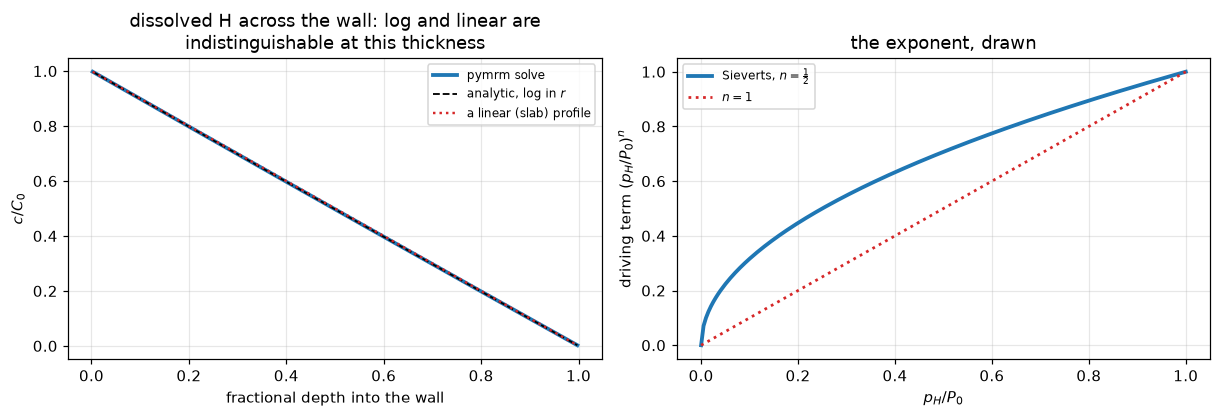

The wall is 2.4 % of the tube radius, so the log profile is barely
distinguishable from a straight line - which is exactly why the alpha_H
identity has almost no power against a wrong geometry. Validation check 2
measures that rather than assuming it.


In [5]:
r_c, c_w, r_f, Q_f = wall_solve(sieverts_c(1.0), 0.0, n_r=200)
ALPHA_FV = Q_f[0]
ALPHA_CF = 2 * np.pi * L0 * D_PD * C_0 / np.log(RO / RI)     # the closed form
c_log = C_0 * (1.0 - np.log(r_c / RI) / np.log(RO / RI))

print("wall solve at unit driving force (p_H = P_0, p'_H = 0), n_r = 200")
print(f"  alpha_H from the pymrm solve   : {ALPHA_FV:.6e} mol/s")
print(f"  alpha_H closed form, Eq. 1     : {ALPHA_CF:.6e} mol/s "
      f"({(ALPHA_FV - ALPHA_CF) / ALPHA_CF:+.2e} relative)")
print(f"  alpha_H PRINTED by Itoh        : {ALPHA_H:.3e} mol/s "
      f"({(ALPHA_FV - ALPHA_H) / ALPHA_H * 100:+.3f} % from the solve)")
print(f"  profile vs the analytic log    : max |dc|/C_0 = "
      f"{np.max(np.abs(c_w - c_log)) / C_0:.2e}")
print(f"  flux across the {len(Q_f)} faces      : spread "
      f"{np.ptp(Q_f) / Q_f.mean():.2e}  (structural - div(J) = 0 is what was solved)")

print("\nwhich of the two readings of '17.0 mm' did Itoh substitute into Eq. 1?")
for label, ri, ro in [("17.0 mm read as ID  (r_i=8.5, r_o=8.7 mm)", 8.5e-3, 8.7e-3),
                      ("17.0 mm read as OD  (r_i=8.3, r_o=8.5 mm)", 8.3e-3, 8.5e-3)]:
    a = alpha_from_wall(ri, ro)
    print(f"  {label}: {a:.4e} mol/s  ({(a - ALPHA_H) / ALPHA_H * 100:+.2f} % vs printed)")
print("  -> the ID reading, decisively. But read that for what it is: it PICKS")
print("     BETWEEN TWO READINGS of one printed sentence. It is not a test of the")
print("     geometry, because the geometry is its own output. The independent")
print("     witness is Figure 1's dimension arrows (see Parameters above), which")
print("     land on the INNER faces of the membrane lines and say the same thing.")

print("\nhow much geometry does the alpha_H identity actually pin down?")
RATIO_LOCUS = np.exp(2 * np.pi * L0 * D_PD * C_0 / ALPHA_H)
print(f"  Eq. 1 constrains only the RATIO: alpha_H = {ALPHA_H:.3e} <=> "
      f"r_o/r_i = {RATIO_LOCUS:.6f} exactly.")
for ri, wall in ((4.25e-3, 1e-4), (RI, DELTA), (17.0e-3, 4e-4)):
    print(f"    (r_i, wall) = ({ri * 1e3:>5.2f} mm, {wall * 1e6:>3.0f} um) -> "
          f"alpha_H = {alpha_from_wall(ri, ri + wall):.4e} mol/s")
print("  All three sit on the same locus. Only the PRINTED 200 um wall turns the")
print("  ratio into a radius, so that number is load-bearing.")
_a_of_ri = lambda r: alpha_from_wall(r, r + DELTA)
RI_LO = brentq(lambda r: (_a_of_ri(r) - ALPHA_H) / ALPHA_H + 0.01, 5e-3, RI)
RI_HI = brentq(lambda r: (_a_of_ri(r) - ALPHA_H) / ALPHA_H - 0.01, RI, 20e-3)
print(f"  Given that wall, agreement degrades to 1 % at r_i = {RI_LO * 1e3:.3f} mm "
      f"and {RI_HI * 1e3:.3f} mm,")
print(f"  a window of {(RI_LO - RI) * 1e6:+.0f}/{(RI_HI - RI) * 1e6:+.0f} um, i.e. "
      f"+-{(RI_HI - RI_LO) / (2 * RI) * 100:.1f} % in r_i. Thickness bites harder:")
for dw in (-10e-6, +10e-6):
    aa = alpha_from_wall(RI, RI + DELTA + dw)
    print(f"    wall {(DELTA + dw) * 1e6:.0f} um at r_i = 8.5 mm -> {aa:.4e} mol/s "
          f"({(aa - ALPHA_H) / ALPHA_H * 100:+.2f} %)")

fig, ax = plt.subplots(1, 2, figsize=(11.2, 3.9))
xd = (r_c - RI) / (RO - RI)
ax[0].plot(xd, c_w / C_0, lw=2.5, label="pymrm solve")
ax[0].plot(xd, c_log / C_0, "k--", lw=1.2, label="analytic, log in $r$")
ax[0].plot(xd, 1 - xd, ":", color="tab:red", lw=1.6, label="a linear (slab) profile")
ax[0].set(xlabel="fractional depth into the wall", ylabel="$c/C_0$",
          title="dissolved H across the wall: log and linear are\n"
                "indistinguishable at this thickness")
ax[0].legend(fontsize=8)
pr = np.linspace(0, 1, 200)
ax[1].plot(pr, np.sqrt(pr), lw=2.5, label=r"Sieverts, $n=\frac{1}{2}$")
ax[1].plot(pr, pr, ":", color="tab:red", lw=1.8, label="$n = 1$")
ax[1].set(xlabel="$p_H/P_0$", ylabel=r"driving term $(p_H/P_0)^n$",
          title="the exponent, drawn")
ax[1].legend(fontsize=8)
fig.tight_layout(); plt.show()
print("The wall is 2.4 % of the tube radius, so the log profile is barely")
print("distinguishable from a straight line - which is exactly why the alpha_H")
print("identity has almost no power against a wrong geometry. Validation check 2")
print("measures that rather than assuming it.")

### 2. The channel — 1-D convection with a nonlinear sink (`S5`)

A tube of the same membrane carrying hydrogen diluted in an inert, with the
permeate side held at a fixed hydrogen mole fraction $y'$ (the large-purge or
vacuum limit; the *coupled* two-channel problem, where the permeate composition
is itself an unknown, is page `H1.4`). Writing $w = u_H/u_H^0$ for the hydrogen
flow scaled on its inlet value, $\beta = u_{\text{inert}}/u_H^0$, and $L$ for
dimensionless axial position,

$$
\frac{\mathrm{d}w}{\mathrm{d}L}
= -\,\Pi\left[\left(\frac{w}{w+\beta}\right)^{n} - (y')^{n}\right],
\qquad w(0) = 1,
\qquad
\boxed{\;\Pi \equiv \frac{\alpha_H}{u_H^0}\sqrt{\frac{P_T}{P_0}}\;}
$$

with $n = \tfrac12$ the printed exponent. **$\Pi$ is the whole problem**: the
membrane's permeation capacity at full driving force, divided by the hydrogen
throughput it has to handle. Everything in sections 3 and 4 is a statement about
$\Pi$.

In pymrm this is `construct_convflux_upwind` with $v = 1$ (the equation is
already in flow-rate form) and `construct_div` with **`nu=0`** — $L$ is axial,
not radial — plus a pointwise sink linearised with `NumJac`. The shape is
`(n_z, 1)`, **not** `(n_z,)`: a bare 1-D shape makes `NumJac`'s default stencil
declare every cell coupled to every other and build a dense Jacobian.

Boundary conditions, outward normal: inlet $w = 1$ (Dirichlet, $a{=}0$,
$b{=}1$), outlet $\partial w/\partial n = 0$ ($a{=}1$, $b{=}0$) — a pure
convective outflow. Leaving the outlet as `None` makes the matrix singular.

In [6]:
NEWTON_ITERS = []   # iteration count of every solve that CONVERGED
NEWTON_FAILS = []   # labels of solves that did not - all of them deliberate breaks


class Permeator:
    """Isothermal plug-flow membrane channel, hydrogen removed by an n-power law.

    dw/dL = -Pi [ (w/(w+beta))^n - yperm^n ],   w(0) = 1,   L in [0, Lend].

    `sink_sign`, `use_mole_fraction`, `nu` and `outlet_dirichlet` exist so the
    validation section can break the model on purpose and watch the agreement
    move. They are not modelling options.
    """

    def __init__(self, Pi, beta, n=0.5, yperm=0.0, n_z=800, Lend=1.0,
                 sink_sign=-1.0, use_mole_fraction=True, nu=0,
                 outlet_dirichlet=False):
        self.Pi, self.beta, self.n, self.yperm = Pi, beta, n, yperm
        self.sink_sign, self.use_mole_fraction = sink_sign, use_mole_fraction
        self.Lend = Lend
        self.z_f = np.linspace(0.0, Lend, n_z + 1)
        self.z_c = 0.5 * (self.z_f[:-1] + self.z_f[1:])
        self.shape = (n_z, 1)              # single field -> (n, 1), never (n,)
        # outward normal, a.dw/dn + b.w = d
        #   inlet  (L=0)   : w = 1      -> a=0, b=1, d=1
        #   outlet (L=Lend): dw/dn = 0  -> a=1, b=0   (convective outflow)
        outlet = ({"a": 0.0, "b": 1.0, "d": 0.0} if outlet_dirichlet
                  else {"a": 1.0, "b": 0.0, "d": 0.0})
        self.bc = ({"a": 0.0, "b": 1.0, "d": 1.0}, outlet)
        conv, conv_bc = construct_convflux_upwind(
            self.shape, self.z_f, self.z_c, self.bc, v=1.0, axis=0)
        self.nu_used = nu
        div = construct_div(self.shape, self.z_f, nu=nu, axis=0)   # nu=0: axial
        self.jac_const = div @ conv
        self.g_const = np.asarray((div @ conv_bc).todense()).reshape((-1, 1))
        self.numjac = NumJac(self.shape)          # pointwise sink: last axis only
        self.w = np.full(self.shape, 1.0)         # deterministic flat guess

    def source(self, w):
        wp = np.maximum(w, 0.0)
        y = wp / (wp + self.beta) if self.use_mole_fraction else wp
        return self.sink_sign * self.Pi * (y ** self.n - self.yperm ** self.n)

    def residual(self, w):
        g_s, jac_s = self.numjac(self.source, w)
        g = self.g_const + self.jac_const @ w.reshape((-1, 1)) - g_s.reshape((-1, 1))
        return g, self.jac_const - jac_s

    def march_guess(self):
        """Initial guess: solve the SAME cell equations one cell at a time.

        First-order upwind on a uniform grid makes the discrete system
        bidiagonal, so cell i couples only to cell i-1 and the whole system can
        be swept forward with a scalar root find:

            (w_i - w_{i-1})/h + Pi [ (w_i/(w_i+beta))^n - y'^n ] = 0.

        That residual is continuous and strictly increasing in w_i, is negative
        at the flux-free floor and positive at w_{i-1}, so a unique root exists
        in between AT EVERY CELL AND EVERY Pi - there is no cell at which the
        discrete problem has no admissible solution. Past the extinction point
        the root decays QUADRATICALLY per cell, underflows to exactly 0 within a
        handful of cells, and w = 0 then satisfies the cell equation identically.

        This is not an independent reference: it is the same equation the pymrm
        operators assemble, written out by hand. It is used only as a starting
        point for the Newton solve, which then certifies it on the assembled
        system. The independent reference stays `exact_half` / `exact_quadrature`.
        """
        h = np.diff(self.z_f)
        # the flux-free floor: w where the driving force vanishes (0 if y' = 0)
        w_stop = (self.beta * self.yperm / (1.0 - self.yperm)) if self.yperm > 0 else 0.0
        f = lambda x: (max(x, 0.0) / (max(x, 0.0) + self.beta)) ** self.n             - self.yperm ** self.n
        w, prev = np.empty(len(h)), 1.0
        for i in range(len(h)):
            g = lambda x: (x - prev) / h[i] + self.Pi * f(x)
            if prev <= w_stop or g(w_stop) >= 0.0:
                prev = w_stop                       # already at the floor
            else:
                prev = brentq(g, w_stop, prev, xtol=1e-300, rtol=8.9e-16, maxiter=500)
            w[i] = prev
        self.w = w.reshape(self.shape)
        return self.w

    def solve(self, tol=1e-12, maxit=100, label=None):
        """Damped Newton, backtracking line search on the residual inf-norm."""
        w = self.w.copy()
        g, J = self.residual(w)
        ng = np.abs(g).max()
        for it in range(maxit):
            if ng < tol:
                self.w = w
                NEWTON_ITERS.append(it)
                return True
            dw = spsolve(J.tocsc(), -np.asarray(g).ravel()).reshape(self.shape)
            lam = 1.0
            while lam > 1e-8:
                w_try = w + lam * dw
                g2, J2 = self.residual(w_try)
                ng2 = np.abs(g2).max()
                if ng2 < (1.0 - 0.5 * lam) * ng + 1e-16:
                    break
                lam *= 0.5
            w, g, J, ng = w_try, g2, J2, ng2
        self.w = w
        NEWTON_FAILS.append(label or (self.n, self.sink_sign, self.nu_used))
        return False


# ---- the exact solutions the pymrm channel is checked against -------------
def G_half(w, beta):
    """Antiderivative for n = 1/2, y' = 0:  dG/dw = sqrt((w + beta)/w).

    Then G(w0) - G(w(L)) = Pi L exactly, and G(0) = 0, so the hydrogen is
    exhausted at the FINITE length L_ext = G(w0)/Pi.
    """
    return np.sqrt(w * (w + beta)) + beta * np.arcsinh(np.sqrt(w / beta))


def exact_half(L, beta, Pi, w0=1.0):
    """w(L) for n = 1/2, y' = 0, by inverting G. No discretisation anywhere."""
    out = []
    for t in np.atleast_1d(G_half(w0, beta) - Pi * np.asarray(L, float)):
        out.append(0.0 if t <= 0.0 else
                   brentq(lambda w: G_half(w, beta) - t, 0.0, w0,
                          xtol=1e-16, rtol=8.9e-16))
    return np.array(out)


def exact_quadrature(L, beta, Pi, n=0.5, yperm=0.0, w0=1.0):
    """w(L) for any n and any permeate loading, by separating and quadrature.

    L(w) = (1/Pi) int_w^{w0} dw' / [ (w'/(w'+beta))^n - yperm^n ], inverted by
    bisection. Shares nothing with the finite-volume assembly.
    """
    f = lambda x: (x / (x + beta)) ** n - yperm ** n
    w_stop = beta * yperm / (1.0 - yperm) if yperm > 0 else 0.0    # flux-free point

    def Lof(w):
        # The integrand blows up at w_stop (that is the physics: the flux-free
        # floor is approached only asymptotically). Every w evaluated here is
        # strictly above it, so quad's warning about the endpoint is noise.
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", IntegrationWarning)
            return quad(lambda x: 1.0 / f(x), w, w0, limit=400)[0] / Pi
    out = []
    for Li in np.atleast_1d(np.asarray(L, float)):
        lo = w_stop * (1.0 + 1e-12) + 1e-300
        if Lof(lo) <= Li:
            out.append(lo)
            continue
        out.append(brentq(lambda w: Lof(w) - Li, lo, w0, xtol=1e-15, rtol=8.9e-16))
    return np.array(out)


def exact_lin(L, beta, Pi, w0=1.0):
    """Exact solution for n = 1, y' = 0:  w + beta ln w = w0 + beta ln w0 - Pi L.

    Elementary, and the logarithm is the point: w = 0 requires L = infinity, so
    a linear pressure law never empties the tube.
    """
    rhs = w0 + beta * np.log(w0) - Pi * np.asarray(L, float)
    out = []
    for r in np.atleast_1d(rhs):
        out.append(brentq(lambda w: w + beta * np.log(w) - r, 1e-300, w0,
                          xtol=1e-300, rtol=8.9e-16))
    return np.array(out)

## Results

### 3. What the exponent ½ actually does

Two consequences, both exact, both easy to check, and both invisible if the law
is only ever written down.

**(a) A ½-law strips its feed completely in a finite length — *if the permeate
side is clean*.** Everything in this subsection is derived at $y' = 0$, and that
condition is not cosmetic: with any permeate loading the tube strips only to the
pressure-matched floor $\beta y'/(1-y')$, the approach to it is asymptotic, and
the finite extinction length disappears entirely. Validation check 5b measures
exactly that. With $y' = 0$, separating the equation gives $G(w_0) - G(w) = \Pi L$ with
$G(w) = \sqrt{w(w+\beta)} + \beta\,\operatorname{arcsinh}\sqrt{w/\beta}$, and
$G(0) = 0$. So $w$ reaches **exactly zero** at the finite length

$$
L_\mathrm{ext} = \frac{G(w_0)}{\Pi},
$$

because $\int_0 \mathrm{d}w/\sqrt{w}$ converges. With $n = 1$ the same integral
is $\int_0 \mathrm{d}w/w$, which diverges: an exponent of 1 gives exponential
decay that never terminates. The capacity at which a unit-length tube *just*
achieves complete stripping is therefore $\Pi_\mathrm{crit} = G(1,\beta)$ — a
number, not a fit.

**(b) Spare capacity is worth its square.** In steady operation the membrane
must export a duty $q$, so the driving mole fraction settles at
$y_H = (q/\alpha_H)^{1/n}$. With $n = \tfrac12$ that is $\Pi^{-2}$; with $n = 1$
it is $\Pi^{-1}$. A membrane with 50× spare capacity needs a driving mole
fraction 2500× smaller under a ½-law and only 50× smaller under a linear law.
That is the whole reason a palladium membrane can hold a reactor's hydrogen
partial pressure down at the $10^{-4}$ level — **against a clean permeate**. If
the permeate is loaded, as in Itoh's own argon-purged reactor, what the reaction
side reaches is set by the permeate composition instead, and the driving
difference goes to zero rather than to $\Pi^{-2}$. The cell below computes both
numbers for his tube, because they differ by a factor of 19 and are easy to
confuse.

In [7]:
# --- the channel that Itoh's own tube would be, run as a separator ----------
# Duty: the H2 his reaction makes at complete conversion, 3 * u_C0. Inert: the
# argon he feeds plus the benzene produced. Every input here is printed.
N_AR = (1.0 - YC0) / YC0
U_H0 = 3.0 * UC0                              # mol/s of H2 to export
U_INERT = UC0 * N_AR + UC0                    # Ar + benzene, mol/s
BETA = U_INERT / U_H0
PI_ITOH = ALPHA_H / U_H0                      # P_T = P_0, so the sqrt factor is 1
PI_CRIT = G_half(1.0, BETA)
L_EXT_ITOH = PI_CRIT / PI_ITOH
Y_REQ_HALF = (1.0 / PI_ITOH) ** 2
Y_REQ_LIN = 1.0 / PI_ITOH

print("Itoh's membrane, USED AS A SEPARATOR ON A CLEAN PERMEATE (y' = 0), for the")
print("duty his reaction sets. This is a hypothetical duty placed on his tube, NOT")
print("a description of his reactor - see the loaded-permeate block below.")
print(f"  hydrogen to export  u_H0 = 3 u_C0 = {U_H0:.3e} mol/s")
print(f"  inert carried along        beta  = {BETA:.3f}")
print(f"  permeation capacity ratio  Pi    = alpha_H / u_H0 = {PI_ITOH:.1f}")
print(f"  critical capacity for L_ext = 1  : Pi_crit = G(1, beta) = {PI_CRIT:.3f}")
print(f"  -> the hydrogen would be exhausted at L_ext = {L_EXT_ITOH:.4f} of the tube,")
print(f"     i.e. the membrane is {PI_ITOH / PI_CRIT:.1f}x larger than the duty needs.")
print(f"  driving mole fraction that duty needs, n = 1/2 : {Y_REQ_HALF:.3e}")
print(f"                                         n = 1   : {Y_REQ_LIN:.3e}"
      f"   ({Y_REQ_LIN / Y_REQ_HALF:.0f}x larger)")
print(f"  halving alpha_H moves the n = 1/2 requirement only to "
      f"{(1 / (0.5 * PI_ITOH)) ** 2:.2e}.")

# --- and what Itoh's REACTOR actually does, which is a different problem -----
# His permeate side is LOADED: an argon purge that accumulates the H2 it strips.
# At the co-current fast-permeation limit both sides carry the same H2 mole
# fraction, from printed numbers only (u_C0, y_C0, v_A0, the measured X).
F_NON_H2 = UC0 * (1.0 + N_AR)                 # non-H2 reaction-side flow, mol/s
Q_BOTH = 3.0 * X_MEAS * UC0 / (F_NON_H2 + VA0)
Y_BOTH = Q_BOTH / (1.0 + Q_BOTH)
print("\nItoh's REACTOR is not that separator: his permeate side is LOADED.")
print(f"  argon purge v_A0 = {VA0:.2e} mol/s, measured conversion X = {X_MEAS}")
print(f"  at the co-current fast-permeation limit both sides carry the SAME H2")
print(f"  mole fraction  y = q/(1+q),  q = 3 X u_C0/(F_0 + v_A0) = {Q_BOTH:.4e}")
print(f"  -> y = {Y_BOTH:.3e}, which is {Y_BOTH / Y_REQ_HALF:.0f}x the {Y_REQ_HALF:.2e}")
print(f"     the clean-permeate separator would need, and the DRIVING difference")
print("     tends to zero, because that is what the ceiling means. Nor is the")
print("     hydrogen stripped in 5.5 % of the length: with y' > 0 there is no")
print("     finite extinction length at all (check 5b).")
print("  What survives, and it is the useful part: Pi = "
      f"{PI_ITOH:.1f} vs Pi_crit = {PI_CRIT:.2f}")
print(f"  means permeation is nowhere near limiting ({PI_ITOH / PI_CRIT:.1f}x spare),")
print("  which is the condition that puts H1.4's model on its co-current")
print("  fast-permeation ceiling - and once there the conversion is a function of")
print("  K_p and the purge split alone, so alpha_H has no observable left to move.")

Itoh's membrane, USED AS A SEPARATOR ON A CLEAN PERMEATE (y' = 0), for the
duty his reaction sets. This is a hypothetical duty placed on his tube, NOT
a description of his reactor - see the loaded-permeate block below.
  hydrogen to export  u_H0 = 3 u_C0 = 8.700e-07 mol/s
  inert carried along        beta  = 1.692
  permeation capacity ratio  Pi    = alpha_H / u_H0 = 51.4
  critical capacity for L_ext = 1  : Pi_crit = G(1, beta) = 2.839
  -> the hydrogen would be exhausted at L_ext = 0.0553 of the tube,
     i.e. the membrane is 18.1x larger than the duty needs.
  driving mole fraction that duty needs, n = 1/2 : 3.788e-04
                                         n = 1   : 1.946e-02   (51x larger)
  halving alpha_H moves the n = 1/2 requirement only to 1.52e-03.

Itoh's REACTOR is not that separator: his permeate side is LOADED.
  argon purge v_A0 = 1.18e-04 mol/s, measured conversion X = 0.997
  at the co-current fast-permeation limit both sides carry the SAME H2
  mole fraction  y = q

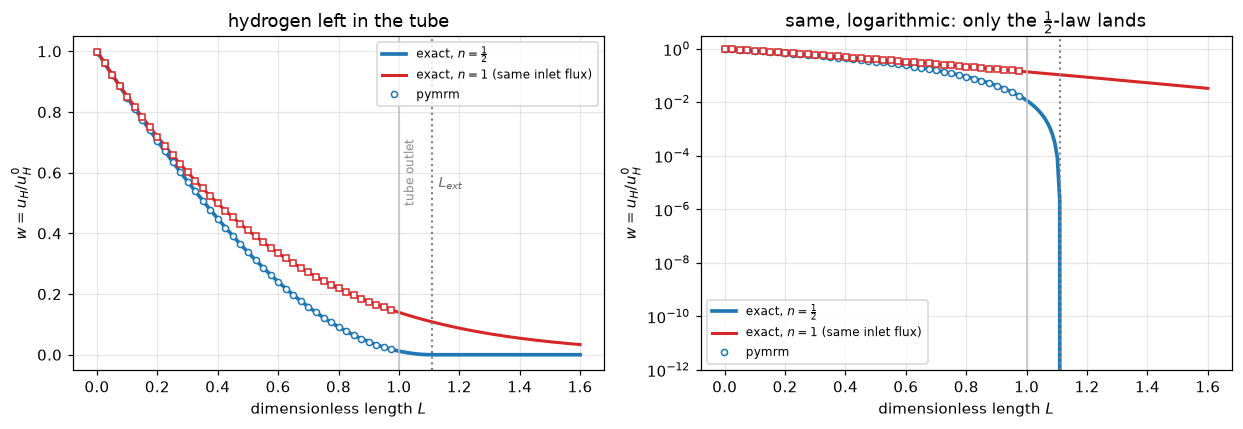

Pi = 2.555 (= 0.90 Pi_crit), so the exact extinction length is
L_ext = 1.1111, just past the outlet. Hydrogen left at L = 1:
  n = 1/2 : pymrm 1.202701e-02, exact 1.187966e-02
  n = 1   : pymrm 1.397740e-01, exact 1.395938e-01   (11.6x more)
Both laws are normalised to the SAME flux at the inlet, so the exponent is
the only difference between them. As the hydrogen thins out, sqrt(y) > y,
so the 1/2-law keeps pulling where the linear law fades - and it reaches
zero at the finite L_ext = 1.1111, while the n = 1 solution obeys
w + beta ln w = 1 - Pi L, whose logarithm sends w -> 0 only as L -> inf.


In [8]:
# --- profiles: the finite extinction of a 1/2-law vs the tail of a 1-law ----
# Compared at equal flux AT THE INLET, so the exponent is the only difference:
#   alpha_n y0^n = alpha_H y0^(1/2)   =>   Pi_n = Pi y0^(1/2 - n)
Y0 = 1.0 / (1.0 + BETA)
PI_DEMO = 0.90 * PI_CRIT                     # L_ext = 1.111: just past the outlet
PI_LIN = PI_DEMO * Y0 ** (0.5 - 1.0)
p_half = Permeator(PI_DEMO, BETA, n=N_EXP, n_z=1600); assert p_half.solve()
p_lin = Permeator(PI_LIN, BETA, n=1.0, n_z=1600); assert p_lin.solve()

Lg = np.linspace(0.0, 1.6, 200)
ex_half, ex_lin = exact_half(Lg, BETA, PI_DEMO), exact_lin(Lg, BETA, PI_LIN)
L_ext_demo = G_half(1.0, BETA) / PI_DEMO

fig, ax = plt.subplots(1, 2, figsize=(11.4, 4.0))
for a, logy in zip(ax, (False, True)):
    a.plot(Lg, ex_half, lw=2.4, color="tab:blue", label=r"exact, $n=\frac{1}{2}$")
    a.plot(Lg, ex_lin, lw=2.0, color="tab:red", label="exact, $n=1$ (same inlet flux)")
    a.plot(p_half.z_c[::40], p_half.w.ravel()[::40], "o", ms=4, color="tab:blue",
           mfc="w", label="pymrm")
    a.plot(p_lin.z_c[::40], p_lin.w.ravel()[::40], "s", ms=4, color="tab:red", mfc="w")
    a.axvline(L_ext_demo, color="0.5", ls=":", lw=1.4)
    a.axvline(1.0, color="0.75", lw=1.0)
    a.set(xlabel="dimensionless length $L$", ylabel="$w = u_H/u_H^0$")
    if logy:
        a.set_yscale("log"); a.set_ylim(1e-12, 3)
        a.set_title(r"same, logarithmic: only the $\frac{1}{2}$-law lands")
    else:
        a.set_title("hydrogen left in the tube")
    a.legend(fontsize=8)
ax[0].text(L_ext_demo + 0.02, 0.55, "$L_{ext}$", fontsize=9, color="0.4")
ax[0].text(1.015, 0.5, "tube outlet", fontsize=8, color="0.55", rotation=90)
fig.tight_layout(); plt.show()
W_HALF_OUT, W_LIN_OUT = p_half.w[-1, 0], p_lin.w[-1, 0]
print(f"Pi = {PI_DEMO:.3f} (= 0.90 Pi_crit), so the exact extinction length is")
print(f"L_ext = {L_ext_demo:.4f}, just past the outlet. Hydrogen left at L = 1:")
print(f"  n = 1/2 : pymrm {W_HALF_OUT:.6e}, exact {exact_half(1.0, BETA, PI_DEMO)[0]:.6e}")
print(f"  n = 1   : pymrm {W_LIN_OUT:.6e}, exact {exact_lin(1.0, BETA, PI_LIN)[0]:.6e}"
      f"   ({W_LIN_OUT / W_HALF_OUT:.1f}x more)")
print("Both laws are normalised to the SAME flux at the inlet, so the exponent is")
print("the only difference between them. As the hydrogen thins out, sqrt(y) > y,")
print("so the 1/2-law keeps pulling where the linear law fades - and it reaches")
print(f"zero at the finite L_ext = {L_ext_demo:.4f}, while the n = 1 solution obeys")
print("w + beta ln w = 1 - Pi L, whose logarithm sends w -> 0 only as L -> inf.")

### 4. When is permeation the limiting resistance?

$\Pi$ answers this on its own, and the answer is a comparison of two lengths.
**Again on a clean permeate side** — $\Pi_\mathrm{crit}$ exists because
$\int_0\mathrm{d}w/\sqrt{w}$ converges, which needs $y' = 0$; with $y' > 0$ the
extinction length is infinite and this map's right-hand axis has no critical
point on it. Under that condition, a tube of dimensionless length 1 exports all
of its hydrogen if and only if $\Pi \ge \Pi_\mathrm{crit} = G(1,\beta)$; the
fraction of the tube the membrane actually needs is
$L_\mathrm{ext} = \Pi_\mathrm{crit}/\Pi$. Below $\Pi_\mathrm{crit}$ the membrane
is the bottleneck and the outlet still carries hydrogen; far above it, the
membrane finishes its job in a short entrance region and **nothing downstream is
sensitive to $\alpha_H$ at all**.

Itoh's membrane sits at $\Pi \approx 51$ against $\Pi_\mathrm{crit} \approx 2.8$.
That ratio — not the 5.5 % stripping length, which belongs to the clean-permeate
separator and not to his loaded reactor — is why page `H1.4` found its measured
conversion completely insensitive to the permeance: permeation is 18× from being
the limiting resistance, which is the condition that puts that model on its
co-current fast-permeation ceiling.

**A numerical note, and it is about Newton rather than about the law.** Started
from a flat guess, the damped Newton solve stalls as soon as the extinction
point enters the domain. That is a **globalisation failure, not an
impossibility**: the discrete cell equation

$$
\frac{w_i - w_{i-1}}{h} + \Pi\left(\frac{w_i}{w_i+\beta}\right)^{1/2} = 0
$$

is continuous and strictly increasing in $w_i$, negative at $w_i = 0$ and
positive at $w_i = w_{i-1}$, so a **unique non-negative root exists at every cell
and every $\Pi$**. Past the front it decays *quadratically per cell*, underflows
to exactly 0 within a handful of cells, and $w = 0$ satisfies the cell equation
thereafter. What defeats the flat start is the Jacobian: the sink's derivative
diverges like $w^{-1/2}$ as $w \to 0$, `NumJac` perturbs with an **absolute**
floor (`eps_jac = 1e-6`), so the differenced derivative is meaningless for the
sub-$10^{-6}$ values the solution takes, and the line search parks the iterate
at a slightly negative $w$ where the `max(w,0)` clip makes the residual
non-smooth.

The fix is six lines: **march the same bidiagonal system cell by cell and use
that as the initial guess** (`Permeator.march_guess`). The cell below runs the
sweep over the *whole* range — including Itoh's own $\Pi = 51$ — trying the flat
guess first and falling back to the march, and reports which points needed it.
The marched solutions are certified on the assembled pymrm system to residual
$5\times10^{-13}$ and converge to the exact solution at first order.

The map is a statement about the *law*: the reaction, the purge and the
equilibrium of `H1.4` are all absent.

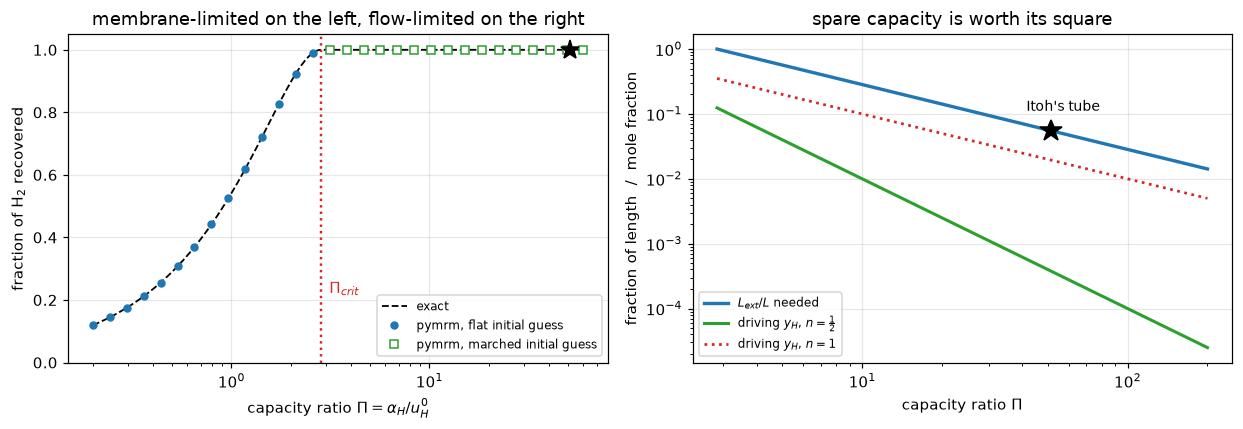

finite-volume sweep over the WHOLE range, Pi = 0.20 to 60.0
  14 points converged from the flat guess (the last at Pi = 2.58 = 0.91 Pi_crit);
  the other 16 needed the marched initial guess, and every one
  of them then converged: min w over the whole sweep = 0.0e+00
  (no negative values anywhere), worst residual 4.6e-13.
  worst |pymrm - exact| outlet fraction over the swept range: 3.57e-04
  So the fixed grid does place the front; only the flat start could not.

Pi_crit = 2.839 at beta = 1.692, for a clean permeate side.
At Itoh's Pi = 51.4 the same tube run as a clean-permeate separator
would need 5.5 % of its length and a driving mole fraction of
3.79e-04. His actual reactor loads the permeate and sits on the
fast-permeation ceiling instead, at y = 7.21e-03 on BOTH sides. Either
way permeation is 18x from limiting, so nothing measured at the
outlet of such a tube constrains alpha_H. That is a property of the
operating point, not of the measurement technique.


In [9]:
PI_FV = np.logspace(np.log10(0.2), np.log10(60.0), 30)
out_fv, seeded, resid, minw = [], [], [], []
for pi in PI_FV:
    p = Permeator(pi, BETA, n_z=800)
    ok = p.solve(label=f"flat start, Pi = {pi:.3g}")   # what the page used to do
    used_march = not ok
    if used_march:
        p.march_guess()                                 # six lines, and it converges
        ok = p.solve()
    assert ok, f"Newton failed even from the march at Pi = {pi}"
    r, _ = p.residual(p.w)
    out_fv.append(p.w[-1, 0]); seeded.append(used_march)
    resid.append(np.abs(r).max()); minw.append(p.w.min())
out_fv, seeded = np.array(out_fv), np.array(seeded)
SWEEP_N_MARCHED = int(seeded.sum())
SWEEP_MIN_W = float(min(minw))
SWEEP_MAX_RESID = float(max(resid))
PI_FLAT_LAST = float(PI_FV[~seeded].max())
PI_EX = np.logspace(np.log10(0.2), np.log10(60.0), 300)
out_ex = np.array([exact_half(1.0, BETA, pi)[0] for pi in PI_EX])
SWEEP_MAXDEV = np.nanmax(np.abs(out_fv - np.array(
    [exact_half(1.0, BETA, pi)[0] for pi in PI_FV])))

fig, ax = plt.subplots(1, 2, figsize=(11.4, 4.0))
ax[0].semilogx(PI_EX, 1 - out_ex, "k--", lw=1.2, label="exact")
ax[0].semilogx(PI_FV[~seeded], 1 - out_fv[~seeded], "o", ms=4.5,
               label="pymrm, flat initial guess")
ax[0].semilogx(PI_FV[seeded], 1 - out_fv[seeded], "s", ms=5.5, mfc="w",
               color="tab:green", label="pymrm, marched initial guess")
ax[0].axvline(PI_CRIT, color="tab:red", ls=":", lw=1.6)
ax[0].text(PI_CRIT * 1.1, 0.22, r"$\Pi_{crit}$", color="tab:red", fontsize=10)
ax[0].set(xlabel=r"capacity ratio $\Pi = \alpha_H/u_H^0$",
          ylabel="fraction of H$_2$ recovered", ylim=(0, 1.05),
          title="membrane-limited on the left, flow-limited on the right")
ax[0].legend(fontsize=8, loc="lower right")

ax[0].plot([PI_ITOH], [1 - exact_half(1.0, BETA, PI_ITOH)[0]], "k*", ms=13, zorder=5)
pig = np.logspace(np.log10(PI_CRIT), np.log10(200), 200)
ax[1].loglog(pig, PI_CRIT / pig, lw=2.2, label=r"$L_{ext}/L$ needed")
ax[1].loglog(pig, (1 / pig) ** 2, lw=2.0, color="tab:green",
             label=r"driving $y_H$, $n=\frac{1}{2}$")
ax[1].loglog(pig, 1 / pig, ":", color="tab:red", lw=1.8,
             label=r"driving $y_H$, $n=1$")
ax[1].plot([PI_ITOH], [PI_CRIT / PI_ITOH], "k*", ms=15, zorder=5)
ax[1].annotate("Itoh's tube", (PI_ITOH, PI_CRIT / PI_ITOH),
               textcoords="offset points", xytext=(-16, 13), fontsize=9)
ax[1].set(xlabel=r"capacity ratio $\Pi$",
          ylabel="fraction of length  /  mole fraction",
          title="spare capacity is worth its square")
ax[1].legend(fontsize=8)
fig.tight_layout(); plt.show()
print(f"finite-volume sweep over the WHOLE range, Pi = {PI_FV[0]:.2f} to {PI_FV[-1]:.1f}")
print(f"  {len(PI_FV) - SWEEP_N_MARCHED} points converged from the flat guess "
      f"(the last at Pi = {PI_FLAT_LAST:.2f} = {PI_FLAT_LAST / PI_CRIT:.2f} Pi_crit);")
print(f"  the other {SWEEP_N_MARCHED} needed the marched initial guess, and every one")
print(f"  of them then converged: min w over the whole sweep = {SWEEP_MIN_W:.1e}")
print(f"  (no negative values anywhere), worst residual {SWEEP_MAX_RESID:.1e}.")
print(f"  worst |pymrm - exact| outlet fraction over the swept range: {SWEEP_MAXDEV:.2e}")
print("  So the fixed grid does place the front; only the flat start could not.")
print()
print(f"Pi_crit = {PI_CRIT:.3f} at beta = {BETA:.3f}, for a clean permeate side.")
print(f"At Itoh's Pi = {PI_ITOH:.1f} the same tube run as a clean-permeate separator")
print(f"would need {PI_CRIT / PI_ITOH * 100:.1f} % of its length and a driving mole fraction of")
print(f"{Y_REQ_HALF:.2e}. His actual reactor loads the permeate and sits on the")
print(f"fast-permeation ceiling instead, at y = {Y_BOTH:.2e} on BOTH sides. Either")
print(f"way permeation is {PI_ITOH / PI_CRIT:.0f}x from limiting, so nothing measured at the")
print("outlet of such a tube constrains alpha_H. That is a property of the")
print("operating point, not of the measurement technique.")

#### 4a. The failure mode, measured

Worth spelling out, because "the solver stopped converging" and "the problem has
no solution" are very different statements and only one of them is true here.
The table below runs the *same* `Permeator`, the *same* `solve()` and the *same*
tolerance from the two initial guesses, at five capacity ratios spanning
$\Pi_\mathrm{crit}$ up to Itoh's own point, and reports what each returns.

In [10]:
print("the same solver, the same tolerance, two initial guesses")
print(f"   {'Pi/Pi_crit':>11}   {'flat guess':<27}{'marched guess'}")
MARCH_FIX = {}
for ratio in (0.95, 1.05, 3.0, 10.0, PI_ITOH / PI_CRIT):
    pi = ratio * PI_CRIT
    a = Permeator(pi, BETA, n_z=800)
    ok_a = a.solve(label=f"flat start, Pi/Pi_crit = {ratio:.3g} (section 4a)")
    b = Permeator(pi, BETA, n_z=800)
    b.march_guess()
    ok_b = b.solve()
    rb, _ = b.residual(b.w)
    MARCH_FIX[ratio] = (ok_a, ok_b, np.abs(rb).max(), b.w.min())
    sa = "converged" if ok_a else f"FAILED, min w = {a.w.min():+.2e}"
    sb = (f"converged, min w = {b.w.min():.1e}, |r| = {np.abs(rb).max():.1e}"
          if ok_b else "FAILED")
    print(f"   {ratio:>11.2f}   {sa:<27}{sb}")
assert all(v[1] for v in MARCH_FIX.values()), "the march must converge everywhere"
MARCH_WORST_RESID = float(max(v[2] for v in MARCH_FIX.values()))
MARCH_MIN_W = float(min(v[3] for v in MARCH_FIX.values()))

print()
print("why the flat start loses it: the extinction tail, from the march at Itoh's Pi")
pm = Permeator(PI_ITOH, BETA, n_z=800); pm.march_guess()
wm = pm.w.ravel()
i0 = int(np.argmax(wm < 1e-3))
i_zero = int(np.argmax(wm == 0.0))
print("   " + "  ".join(f"{x:.2e}" for x in wm[i0 - 1:i_zero]))
print(f"   Each cell squares the one before it, so {i_zero - i0} cells after w drops")
print(f"   below 1e-3 it has underflowed to exactly 0, and stays 0 for the")
print(f"   remaining {len(wm) - i_zero} of {len(wm)} cells. NumJac perturbs with an ABSOLUTE")
print("   1e-6 (`eps_jac`, pymrm/numjac.py), so across that whole tail the")
print("   differenced Jacobian of a w^(1/2) sink is meaningless - which is what")
print("   the flat-start line search walks into.")
print()
print("   the front itself is placed to O(h), and refining shows it:")
print(f"   {'n_z':>7}{'first cell with w = 0':>24}{'L - L_ext':>13}")
for n in (800, 3200, 12800):
    q = Permeator(PI_ITOH, BETA, n_z=n); q.march_guess()
    zf = q.z_f[int(np.argmax(q.w.ravel() == 0.0))]
    print(f"   {n:>7}{zf:>24.5f}{zf - PI_CRIT / PI_ITOH:>13.5f}")
print(f"   against the exact L_ext = {PI_CRIT / PI_ITOH:.5f}. The offset is the width of")
print("   the underflow tail, a fixed number of CELLS, so it shrinks like h.")
print("   This is the same trap page H1.4 records; the fix there and here is to")
print("   give Newton a starting point inside the basin, not to change the model.")

the same solver, the same tolerance, two initial guesses
    Pi/Pi_crit   flat guess                 marched guess
          0.95   converged                  converged, min w = 3.2e-03, |r| = 5.4e-13


          1.05   FAILED, min w = -2.05e-06  converged, min w = 0.0e+00, |r| = 1.3e-13


          3.00   FAILED, min w = -1.31e-06  converged, min w = 0.0e+00, |r| = 2.2e-13


         10.00   FAILED, min w = -5.99e-07  converged, min w = 0.0e+00, |r| = 1.2e-13


         18.10   FAILED, min w = -1.64e-07  converged, min w = 0.0e+00, |r| = 1.4e-13

why the flat start loses it: the extinction tail, from the march at Itoh's Pi
   1.71e-03  5.53e-04  8.84e-05  3.00e-06  3.67e-09  5.53e-15  1.25e-26  6.45e-50  1.70e-96  1.19e-189
   Each cell squares the one before it, so 9 cells after w drops
   below 1e-3 it has underflowed to exactly 0, and stays 0 for the
   remaining 747 of 800 cells. NumJac perturbs with an ABSOLUTE
   1e-6 (`eps_jac`, pymrm/numjac.py), so across that whole tail the
   differenced Jacobian of a w^(1/2) sink is meaningless - which is what
   the flat-start line search walks into.

   the front itself is placed to O(h), and refining shows it:
       n_z   first cell with w = 0    L - L_ext
       800                 0.06625      0.01100
      3200                 0.05813      0.00287
     12800                 0.05609      0.00084
   against the exact L_ext = 0.05525. The offset is the width of
   the underflow tail, a fixed nu

### 5. What a departure from ½ means

Sieverts' law assumes the surface steps are fast enough to keep the dissolved
hydrogen in equilibrium with the gas at each face. Put a **finite** surface step
in series with the wall and that assumption breaks. The model needs no physics
beyond the mechanism already written down: with $\theta = c/C_0$ the scaled
dissolved concentration and $\pi = p/P_0$ the scaled pressure, and writing $a$
for the surface exchange conductance (mol/s at unit driving) and $\alpha_H$ for
the wall conductance,

$$
q = a\left(\pi_1 - \theta_1^2\right)
  = \alpha_H\left(\theta_1 - \theta_2\right)
  = a\left(\theta_2^2 - \pi_2\right),
\qquad
\lambda \equiv \frac{\alpha_H}{a}.
$$

The three expressions are the near surface, the wall and the far surface
carrying the same flux; the **squares** are the dissociative stoichiometry,
which is where the ½ came from in the first place. Both limits are analytic:
$\lambda \to 0$ (fast surface) returns $q = \alpha_H(\sqrt{\pi_1} -
\sqrt{\pi_2})$, Eq. 1 exactly; $\lambda \to \infty$ gives $q =
\tfrac{a}{2}(\pi_1 - \pi_2)$, linear in pressure. In between there is no power
law at all, only a **local** apparent exponent $n_\mathrm{app} = \partial \ln
q/\partial \ln \pi_1$ that depends on the pressure at which it is measured.

Two things this construction is, and is not. It **is** a derivation from the
mechanism, with one dimensionless group and no fitted constants. It is **not**
in Itoh, who assumes the exponent and never tests it, and it is compared with no
measurement here. Read the numbers below as "what a measured exponent would
imply", never as a result about real palladium.

apparent exponent produced by a surface step in series with the wall
  lambda = alpha_H/a        n_app at p/P0=0.5   at p/P0=0.05
  0.0001                               0.5030         0.5054
  0.01                                 0.5329         0.5620
  0.1                                  0.6176         0.7143
  1                                    0.8381         0.9321
  10                                   0.9762         0.9922
  1000                                 0.9998         0.9999
  limits (analytic): lambda -> 0 gives exactly 1/2, lambda -> inf gives 1
  n_app = 0.55 at p/P0 = 0.5 needs lambda = 0.0215
  n_app = 0.60 at p/P0 = 0.5 needs lambda = 0.0746
  n_app = 0.75 at p/P0 = 0.5 needs lambda = 0.443
  n_app = 0.90 at p/P0 = 0.5 needs lambda = 1.97

putting a scale on lambda for Itoh's tube, from printed numbers only:
  membrane area 2 pi r_i l_0 = 7.477e-03 m^2
  wall conductance alpha_H   = 4.47e-05 mol/s  = 5.978e-03 mol/m^2/s at unit driving
  so lambda = 1 means a surf

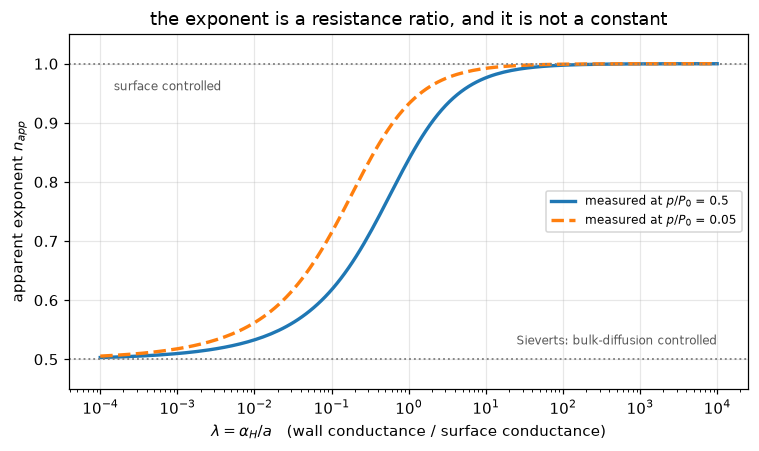

The two curves differ, and that is the useful part: with a surface step in
series the flux is NOT a power law, so a fitted exponent depends on the
pressure range it was fitted over. Note also which way thickness pushes:
alpha_H = 2 pi l D C_0 / ln(r_o/r_i) RISES as the wall thins, while the
surface conductance a does not, so lambda = alpha_H/a rises and THINNER
membranes drift toward n = 1. That is the standard reason very thin Pd
films stop obeying a square root, and it drops out of this construction
without having been put in.


In [11]:
def q_series(pi1, lam, pi2=0.0):
    """Flux through (surface | wall | surface) in series, scaled on alpha_H.

    Eliminating theta_1 and theta_2 leaves
        (q + sqrt(lam q + pi2))^2 = pi1 - lam q,
    solved here for the scaled flux q. Reduces to sqrt(pi1) - sqrt(pi2) at
    lam -> 0 and to (pi1 - pi2)/(2 lam) at lam -> inf.
    """
    if lam <= 0.0:
        return np.sqrt(pi1) - np.sqrt(pi2)
    f = lambda q: (q + np.sqrt(lam * q + pi2)) ** 2 - (pi1 - lam * q)
    hi = np.sqrt(pi1)
    while f(hi) < 0:
        hi *= 2.0
    return brentq(f, 1e-300, hi, xtol=1e-18, rtol=8.9e-16)


def n_apparent(pi1, lam, d=1e-4):
    """Local exponent d ln q / d ln pi1 at pi1, with the permeate side at zero."""
    lo = np.log(q_series(pi1 * np.exp(-d), lam))
    hi = np.log(q_series(pi1 * np.exp(+d), lam))
    return (hi - lo) / (2 * d)


LAMS = np.logspace(-4, 4, 160)
n_at = {pi: np.array([n_apparent(pi, l) for l in LAMS]) for pi in (0.5, 0.05)}

print("apparent exponent produced by a surface step in series with the wall")
print(f"  {'lambda = alpha_H/a':<24}{'n_app at p/P0=0.5':>19}{'at p/P0=0.05':>15}")
for lam in (1e-4, 1e-2, 0.1, 1.0, 10.0, 1e3):
    print(f"  {lam:<24g}{n_apparent(0.5, lam):>19.4f}{n_apparent(0.05, lam):>15.4f}")
print("  limits (analytic): lambda -> 0 gives exactly 1/2, lambda -> inf gives 1")
LAM_AT = {}
for tgt in (0.55, 0.60, 0.75, 0.90):
    LAM_AT[tgt] = np.exp(brentq(lambda l: n_apparent(0.5, np.exp(l)) - tgt,
                                np.log(1e-6), np.log(1e8), xtol=1e-12))
    print(f"  n_app = {tgt:.2f} at p/P0 = 0.5 needs lambda = {LAM_AT[tgt]:.3g}")

A_MEM = 2 * np.pi * RI * L0
print("\nputting a scale on lambda for Itoh's tube, from printed numbers only:")
print(f"  membrane area 2 pi r_i l_0 = {A_MEM:.3e} m^2")
print(f"  wall conductance alpha_H   = {ALPHA_H:.2e} mol/s"
      f"  = {ALPHA_H / A_MEM:.3e} mol/m^2/s at unit driving")
print(f"  so lambda = 1 means a surface exchange rate of {ALPHA_H / A_MEM:.2e} "
      "mol/m^2/s,")
print(f"  and a 10 % shift of the exponent (n_app = 0.55) appears already at")
print(f"  lambda = {LAM_AT[0.55]:.3g}, i.e. a surface only "
      f"{1 / LAM_AT[0.55]:.0f}x faster than the wall.")
print("  Itoh prints no surface kinetics, so his membrane CANNOT be placed on")
print("  this axis from this source. The chart says what a measured exponent")
print("  would imply; it says nothing about what palladium does.")

fig, ax = plt.subplots(figsize=(7.0, 4.2))
for pi, style in zip((0.5, 0.05), ("-", "--")):
    ax.semilogx(LAMS, n_at[pi], style, lw=2.2, label=f"measured at $p/P_0$ = {pi}")
ax.axhline(0.5, color="0.5", ls=":", lw=1.2)
ax.axhline(1.0, color="0.5", ls=":", lw=1.2)
ax.text(25, 0.525, "Sieverts: bulk-diffusion controlled", fontsize=8, color="0.35")
ax.text(1.5e-4, 0.955, "surface controlled", fontsize=8, color="0.35")
ax.set(xlabel=r"$\lambda = \alpha_H / a$   (wall conductance / surface conductance)",
       ylabel=r"apparent exponent $n_{app}$", ylim=(0.45, 1.05),
       title="the exponent is a resistance ratio, and it is not a constant")
ax.legend(fontsize=8, loc="center right")
fig.tight_layout(); plt.show()
print("The two curves differ, and that is the useful part: with a surface step in")
print("series the flux is NOT a power law, so a fitted exponent depends on the")
print("pressure range it was fitted over. Note also which way thickness pushes:")
print("alpha_H = 2 pi l D C_0 / ln(r_o/r_i) RISES as the wall thins, while the")
print("surface conductance a does not, so lambda = alpha_H/a rises and THINNER")
print("membranes drift toward n = 1. That is the standard reason very thin Pd")
print("films stop obeying a square root, and it drops out of this construction")
print("without having been put in.")

## Validation

Six checks. Exactly **one** of them compares with a number from the source, and
that number is itself a calculation rather than a measurement — Itoh reports no
permeation experiment. The rest are internal identities and closed-form limits.
Every agreement number below is followed by a deliberate break test, because an
agreement is worth exactly what it would cost to break.

**Deviation convention throughout: (model − reference)/reference.**

In [12]:
AGREE = {}

print("check 1 - the one number the source prints: alpha_H = 4.47e-5 mol/s")
print("   Derived from Eq. 1's own inputs (D, C_0, l_0, r_i, r_o) by a pymrm")
print("   radial solve, NOT by evaluating Eq. 1's formula.")
DEV_ALPHA = (ALPHA_FV - ALPHA_H) / ALPHA_H
AGREE["alpha_H_dev_vs_printed_pct"] = DEV_ALPHA * 100
print(f"     pymrm solve {ALPHA_FV:.5e}  vs printed {ALPHA_H:.3e}"
      f"   -> {DEV_ALPHA * 100:+.3f} %")
print("   The printed value carries three significant figures, so it pins the")
print(f"   derivation only to about +-0.1 %; the deviation is "
      f"{abs(DEV_ALPHA) * 100:.3f} %.")
print()
print("   READ THIS CHECK EXACTLY. It tests the transcription of D, C_0, l_0 and")
print("   the 200 um wall, the structure of Eq. 1, and the radial assembly -")
print("   GIVEN the geometry. It does NOT test the geometry, because the radii")
print("   were SELECTED by requiring this same identity to close: the check chose")
print("   them, so it cannot catch them being wrong. What it can do, and does, is")
print("   discriminate the two candidate readings of the printed '17.0 mm' by")
print("   2.4 % against a 0.03 % residual. The independent evidence about the")
print("   geometry is Figure 1's dimension arrows (Parameters, above), which are")
print("   read from the drawing and never from alpha_H.")
print("   It also cannot test the physics of the law: nothing here was measured.")

check 1 - the one number the source prints: alpha_H = 4.47e-5 mol/s
   Derived from Eq. 1's own inputs (D, C_0, l_0, r_i, r_o) by a pymrm
   radial solve, NOT by evaluating Eq. 1's formula.
     pymrm solve 4.46857e-05  vs printed 4.470e-05   -> -0.032 %
   The printed value carries three significant figures, so it pins the
   derivation only to about +-0.1 %; the deviation is 0.032 %.

   READ THIS CHECK EXACTLY. It tests the transcription of D, C_0, l_0 and
   the 200 um wall, the structure of Eq. 1, and the radial assembly -
   GIVEN the geometry. It does NOT test the geometry, because the radii
   were SELECTED by requiring this same identity to close: the check chose
   them, so it cannot catch them being wrong. What it can do, and does, is
   discriminate the two candidate readings of the printed '17.0 mm' by
   2.4 % against a 0.03 % residual. The independent evidence about the
   geometry is Figure 1's dimension arrows (Parameters, above), which are
   read from the drawing and

In [13]:
print("check 2 - breaking the wall solve on purpose")
print("   Each row injects one defect and reports the alpha_H that comes out.")
print()
print(f"   {'injected defect':<44}{'alpha_H [mol/s]':>17}{'vs printed':>13}")
BREAK1 = {}


def _rep(label, a):
    BREAK1[label] = a
    print(f"   {label:<44}{a:>17.4e}{(a - ALPHA_H) / ALPHA_H * 100:>+12.2f} %")


_rep("none (baseline: nu=1, n_r=200)", ALPHA_FV)
_rep("nu=0: Cartesian cell volumes", alpha_from_wall(nu=0))
_rep("nu=2: spherical cell volumes", alpha_from_wall(nu=2))
_rep("n_r = 3 (a deliberately coarse grid)", alpha_from_wall(n_r=3))
_rep("radii from the '17.0 mm OD' reading", alpha_from_wall(8.3e-3, 8.5e-3))
_rep("wall 10x thicker (r_o = r_i + 2 mm)", alpha_from_wall(RI, RI + 10 * DELTA))
_rep("D read as 9.23e-9 (one digit slipped)", alpha_from_wall(D=10 * D_PD))

GEOM_THIN = abs(BREAK1["nu=0: Cartesian cell volumes"] - ALPHA_FV) / ALPHA_FV
a_thick_1 = alpha_from_wall(RI, 3 * RI, nu=1)
a_thick_0 = alpha_from_wall(RI, 3 * RI, nu=0)
GEOM_THICK = abs(a_thick_0 - a_thick_1) / a_thick_1
GRID_BLIND = abs(BREAK1["n_r = 3 (a deliberately coarse grid)"] - ALPHA_FV) / ALPHA_FV
AGREE["wall_nu0_break_thin_pct"] = GEOM_THIN * 100
AGREE["wall_nu0_break_thick_pct"] = GEOM_THICK * 100
print()
print("   Read this honestly. Deviations in this table are quoted against the")
print("   PRINTED alpha_H; the percentages quoted in the prose below are against")
print("   the BASELINE SOLVE, which itself sits -0.032 % from printed. The nu=0")
print("   row is the same defect either way: "
      f"{(BREAK1['nu=0: Cartesian cell volumes'] - ALPHA_FV) / ALPHA_FV * 100:+.2f} %"
      " vs the baseline,")
print(f"   {(BREAK1['nu=0: Cartesian cell volumes'] - ALPHA_H) / ALPHA_H * 100:+.2f} %"
      " vs printed.")
print(f"   * A wrong `nu` moves alpha_H by only {GEOM_THIN * 100:.2f} % on this wall,")
print("     because the wall is 2.4 % of the tube radius and a log profile that")
print("     shallow is nearly a straight line. Check 1 is therefore WEAK against")
print("     geometry: it would catch a factor-10 slip in D instantly and a wrong")
print(f"     nu only marginally. On a wall with r_o/r_i = 3 the same defect moves")
print(f"     the answer by {GEOM_THICK * 100:.0f} %, so the assembly is right - it is the")
print("     thin wall, not the code, that makes the identity insensitive here.")
print(f"   * A coarse grid is invisible too ({GRID_BLIND:.1e} relative at n_r = 3):")
print("     the flux of a log profile is recovered almost exactly by very few")
print("     cells. Check 3 is the one that measures the discretisation.")
_pc = lambda k: (BREAK1[k] - ALPHA_H) / ALPHA_H * 100
print("   * What check 1 DOES catch decisively is a wrong constant - a slipped")
print(f"     digit in D moves it by {_pc('D read as 9.23e-9 (one digit slipped)'):+.0f} %, "
      f"a 10x wall by {_pc('wall 10x thicker (r_o = r_i + 2 mm)'):+.0f} %. It does NOT catch")
print("     a wrong pair of radii, because it is what chose them; the radii row")
print("     in this table is the discrimination of two readings, not a break.")
print("     And it constrains only r_o/r_i, so the printed 200 um wall carries")
print("     the geometry (section 1a puts the window at +-1 % in r_i).")

check 2 - breaking the wall solve on purpose
   Each row injects one defect and reports the alpha_H that comes out.

   injected defect                               alpha_H [mol/s]   vs printed
   none (baseline: nu=1, n_r=200)                     4.4686e-05       -0.03 %
   nu=0: Cartesian cell volumes                       4.4168e-05       -1.19 %
   nu=2: spherical cell volumes                       4.5207e-05       +1.13 %
   n_r = 3 (a deliberately coarse grid)               4.4686e-05       -0.03 %
   radii from the '17.0 mm OD' reading                4.3646e-05       -2.36 %
   wall 10x thicker (r_o = r_i + 2 mm)                4.9181e-06      -89.00 %
   D read as 9.23e-9 (one digit slipped)              4.4686e-04     +899.68 %

   Read this honestly. Deviations in this table are quoted against the
   PRINTED alpha_H; the percentages quoted in the prose below are against
   the BASELINE SOLVE, which itself sits -0.032 % from printed. The nu=0
   row is the same defect either 

In [14]:
print("check 3 - grid convergence of the wall solve against the closed form")
prev, err = None, None
for n in (5, 10, 20, 40, 80, 160, 320):
    a = alpha_from_wall(n_r=n)
    err = abs(a - ALPHA_CF) / ALPHA_CF
    order = "" if prev is None else f"    order {np.log2(prev / err):.2f}"
    print(f"     n_r = {n:>4}    rel. error {err:.3e}{order}")
    prev = err
AGREE["wall_grid_rel_err_n320"] = err
print("   Second order, as a centred flux on a smooth solution should be. The two")
print("   routes share no code - one is an spsolve on assembled operators, the")
print("   other is a logarithm - but the check still cannot fail for the right")
print("   reason: it measures the discretisation, not the physics.")

print()
print("check 4 - a wall the closed form cannot handle")
print("   The point of solving rather than quoting. Let D vary across the wall")
print("   (hypothetical: no such profile is printed anywhere). The reference is")
print("   then the resistance integral Q = 2 pi l0 dc / int dr/(r D(r)), by")
print("   quadrature - a genuinely independent route.")
Dprof = lambda r: D_PD * (1.0 + 1.0 * (r - RI) / (RO - RI))     # D doubles across
r_c2, c2, r_f2, Q_f2 = wall_solve(sieverts_c(1.0), 0.0, n_r=400, Dprofile=Dprof)
R_int = quad(lambda r: 1.0 / (r * Dprof(r)), RI, RO, limit=200)[0]
Q_REF = 2 * np.pi * L0 * C_0 / R_int
DEV_GRAD = (Q_f2[0] - Q_REF) / Q_REF
AGREE["graded_D_fv_vs_quadrature_rel"] = abs(DEV_GRAD)
print(f"     pymrm                {Q_f2[0]:.6e} mol/s")
print(f"     quadrature reference {Q_REF:.6e} mol/s   -> {DEV_GRAD:+.2e} relative")
print(f"     (a uniform-D closed form would give {ALPHA_CF:.4e}, "
      f"{(ALPHA_CF - Q_REF) / Q_REF * 100:+.1f} % off)")
_, _, _, Qb = wall_solve(sieverts_c(1.0), 0.0, n_r=400, nu=0, Dprofile=Dprof)
print(f"     break test, same graded D with nu=0: {Qb[0]:.6e} mol/s"
      f"  ({(Qb[0] - Q_REF) / Q_REF * 100:+.2f} %)")
print("     - the quadrature reference does move when the assembly is broken.")

check 3 - grid convergence of the wall solve against the closed form
     n_r =    5    rel. error 7.209e-07
     n_r =   10    rel. error 3.155e-07    order 1.19
     n_r =   20    rel. error 9.579e-08    order 1.72
     n_r =   40    rel. error 2.606e-08    order 1.88
     n_r =   80    rel. error 6.779e-09    order 1.94
     n_r =  160    rel. error 1.728e-09    order 1.97
     n_r =  320    rel. error 4.361e-10    order 1.99
   Second order, as a centred flux on a smooth solution should be. The two
   routes share no code - one is an spsolve on assembled operators, the
   other is a logarithm - but the check still cannot fail for the right
   reason: it measures the discretisation, not the physics.

check 4 - a wall the closed form cannot handle
   The point of solving rather than quoting. Let D vary across the wall
   (hypothetical: no such profile is printed anywhere). The reference is
   then the resistance integral Q = 2 pi l0 dc / int dr/(r D(r)), by
   quadrature - a genuinel

In [15]:
print("check 5 - the channel against its exact solution, and its grid ladder")
print("   Pi = 0.90 Pi_crit, so the hydrogen is not exhausted inside the domain.")
print("   The reference is the inverted antiderivative G, which shares no code")
print("   with the finite-volume assembly.")
print()
print(f"   {'n_z':>6}{'max |w_fv - w_exact|':>24}{'order':>9}{'Newton its':>12}")
prev, err = None, None
for n in (100, 200, 400, 800, 1600, 3200):
    p = Permeator(PI_DEMO, BETA, n_z=n)
    k0 = len(NEWTON_ITERS)
    assert p.solve(), f"Newton failed at n_z={n}"
    err = np.max(np.abs(p.w.ravel() - exact_half(p.z_c, BETA, PI_DEMO)))
    order = "" if prev is None else f"{np.log2(prev / err):>9.2f}"
    print(f"   {n:>6}{err:>24.3e}{order:>9}{NEWTON_ITERS[k0]:>12}")
    ORDER_LAST = None if prev is None else np.log2(prev / err)
    prev = err
AGREE["channel_fv_vs_exact_maxabs_n3200"] = err
AGREE["channel_convergence_order"] = float(ORDER_LAST)
print(f"   measured order over the last refinement: {ORDER_LAST:.2f}"
      "  (first-order upwind)")
AGREE["channel_sweep_maxdev"] = float(SWEEP_MAXDEV)

print()
print("   the extinction length, extracted from the pymrm solution:")
p = Permeator(PI_DEMO, BETA, n_z=3200); assert p.solve()
L_front = p.z_c + G_half(np.maximum(p.w.ravel(), 0.0), BETA) / PI_DEMO
L_EXT_EXACT = G_half(1.0, BETA) / PI_DEMO
DEV_FRONT = np.max(np.abs(L_front - L_EXT_EXACT)) / L_EXT_EXACT
AGREE["extinction_length_rel_err"] = DEV_FRONT
print("     L + G(w(L))/Pi must equal L_ext at every cell.")
print(f"     exact L_ext = {L_EXT_EXACT:.6f}; the worst cell deviates by "
      f"{DEV_FRONT:.2e} relative.")

print()
print("   check 5a - the same ladder ABOVE Pi_crit, where the extinction point is")
print(f"   inside the domain. Pi = {PI_ITOH:.1f} (Itoh's own), marched initial guess.")
print(f"   {'n_z':>6}{'max |w_fv - w_exact|':>24}{'order':>9}{'cells at w = 0':>16}")
prev, err = None, None
for n in (200, 400, 800, 1600, 3200):
    p = Permeator(PI_ITOH, BETA, n_z=n)
    p.march_guess()
    assert p.solve(), f"marched Newton failed at n_z={n}"
    assert p.w.min() >= 0.0, "the marched solution must be non-negative"
    err = np.max(np.abs(p.w.ravel() - exact_half(p.z_c, BETA, PI_ITOH)))
    order = "" if prev is None else f"{np.log2(prev / err):>9.2f}"
    print(f"   {n:>6}{err:>24.3e}{order:>9}{int((p.w == 0).sum()):>16}")
    ORDER_HIGHPI = None if prev is None else np.log2(prev / err)
    prev = err
AGREE["channel_highPi_fv_vs_exact_maxabs_n3200"] = err
AGREE["channel_highPi_convergence_order"] = float(ORDER_HIGHPI)
AGREE["marched_worst_residual"] = MARCH_WORST_RESID
AGREE["marched_min_w"] = MARCH_MIN_W
print(f"   first order ({ORDER_HIGHPI:.2f}) and every value non-negative, so the")
print("   fixed grid resolves the free boundary to O(h) - what the flat start")
print("   could not do was find it, not represent it.")

print()
print("   check 5b - the same channel with a loaded permeate (y' > 0), against")
print("   an independent quadrature reference:")
for yp in (1e-4, 1e-2):
    p = Permeator(PI_DEMO, BETA, yperm=yp, n_z=3200); assert p.solve()
    idx = np.arange(199, 3200, 400)
    ref = exact_quadrature(p.z_c[idx], BETA, PI_DEMO, yperm=yp)
    e2 = np.max(np.abs(p.w.ravel()[idx] - ref))
    w_stop = BETA * yp / (1 - yp)
    AGREE[f"channel_yperm_{yp:.0e}_fv_vs_quad"] = e2
    print(f"     y' = {yp:.0e}:  max |fv - quadrature| = {e2:.2e};  outlet "
          f"{p.w[-1, 0]:.5e}  vs the flux-free floor {w_stop:.5e}")
print("     With a loaded permeate the 1/2-law no longer strips to zero: it")
print("     strips to the pressure-matched floor beta y'/(1 - y'), and reaches")
print("     it only asymptotically. The finite extinction length of section 3 is")
print("     specific to a clean permeate side.")

check 5 - the channel against its exact solution, and its grid ladder
   Pi = 0.90 Pi_crit, so the hydrogen is not exhausted inside the domain.
   The reference is the inverted antiderivative G, which shares no code
   with the finite-volume assembly.

      n_z    max |w_fv - w_exact|    order  Newton its
      100               7.719e-03                    8
      200               3.876e-03     0.99           8
      400               1.942e-03     1.00           9
      800               9.722e-04     1.00           9
     1600               4.864e-04     1.00           9


     3200               2.432e-04     1.00           9
   measured order over the last refinement: 1.00  (first-order upwind)

   the extinction length, extracted from the pymrm solution:


     L + G(w(L))/Pi must equal L_ext at every cell.
     exact L_ext = 1.111111; the worst cell deviates by 1.70e-04 relative.

   check 5a - the same ladder ABOVE Pi_crit, where the extinction point is
   inside the domain. Pi = 51.4 (Itoh's own), marched initial guess.
      n_z    max |w_fv - w_exact|    order  cells at w = 0
      200               7.133e-02                      181
      400               3.743e-02     0.93             369


      800               1.915e-02     0.97             747
     1600               9.680e-03     0.98            1502
     3200               4.867e-03     0.99            3014
   first order (0.99) and every value non-negative, so the
   fixed grid resolves the free boundary to O(h) - what the flat start
   could not do was find it, not represent it.

   check 5b - the same channel with a loaded permeate (y' > 0), against
   an independent quadrature reference:
     y' = 1e-04:  max |fv - quadrature| = 2.24e-04;  outlet 1.95366e-02  vs the flux-free floor 1.69222e-04
     y' = 1e-02:  max |fv - quadrature| = 1.91e-04;  outlet 1.15420e-01  vs the flux-free floor 1.70914e-02
     With a loaded permeate the 1/2-law no longer strips to zero: it
     strips to the pressure-matched floor beta y'/(1 - y'), and reaches
     it only asymptotically. The finite extinction length of section 3 is
     specific to a clean permeate side.


In [16]:
print("check 6 - breaking the channel on purpose")
print("   Reference: the exact G solution. The baseline is the O(h) error of the")
print("   n_z = 800 row above.")
print()
print(f"   {'injected defect':<50}{'max |w_fv - exact|':>20}")
BREAK2 = {}


def _rep2(label, **kw):
    p = Permeator(PI_DEMO, BETA, n_z=800, **kw)
    ok = p.solve()
    e = np.max(np.abs(p.w.ravel() - exact_half(p.z_c, BETA, PI_DEMO)))
    BREAK2[label] = (e, ok)
    note = ("" if ok else ("   (assembly singular)" if not np.isfinite(e)
                           else "   (Newton did not converge)"))
    print(f"   {label:<50}{e:>20.3e}{note}")
    return e


BASE_LABEL = "none (baseline, n_z = 800)"
E_BASE = _rep2(BASE_LABEL)
_rep2("sink sign flipped (+ instead of -)", sink_sign=+1.0)
_rep2("mole fraction replaced by the flow w itself", use_mole_fraction=False)
_rep2("exponent n = 1 instead of 1/2", n=1.0)
_rep2("nu = 1 in construct_div (radial, not axial)", nu=1)
_rep2("outlet forced to w = 0 (Dirichlet, not outflow)", outlet_dirichlet=True)
_conv = {k: v for k, (v, ok) in BREAK2.items()
         if k != BASE_LABEL and ok and np.isfinite(v)}
_fin = {k: v for k, (v, ok) in BREAK2.items()
        if k != BASE_LABEL and np.isfinite(v)}
RATIO_MIN = min(_conv.values()) / E_BASE
RATIO_MIN_ALL = min(_fin.values()) / E_BASE
AGREE["channel_break_min_ratio"] = float(RATIO_MIN)
AGREE["channel_break_min_ratio_incl_nonconverged"] = float(RATIO_MIN_ALL)
print()
print(f"   Quote this over the breaks whose solve CONVERGED, because an error")
print(f"   read off a non-solution is a statement about a failed solve rather")
print(f"   than about a wrong answer. {len(_conv)} of the five defects converged to a")
print(f"   wrong ANSWER, and both moved the error by at least {RATIO_MIN:.0f}x the baseline")
print(f"   (the larger, {max(_conv.values()) / E_BASE:.0f}x, is the flipped sink sign).")
print("   Two more broke the solve outright rather than the")
print(f"   answer - substituting w for the mole fraction ({_fin['mole fraction replaced by the flow w itself'] / E_BASE:.0f}x, not converged)")
print(f"   and nu = 1 ({_fin['nu = 1 in construct_div (radial, not axial)'] / E_BASE:.0f}x, not converged) - and the outlet-Dirichlet")
print("   variant makes the assembly singular. Non-convergence is itself a break")
print(f"   signal, but the honest headline number is {RATIO_MIN:.0f}x, not "
      f"{RATIO_MIN_ALL:.0f}x.")
print("   Check 5 therefore has real power against the sink, the driving")
print("   force, the exponent, the geometry and the outlet condition. It has NO")
print("   power against the value of alpha_H itself: alpha_H enters both routes")
print("   only through Pi, so any error in it cancels exactly. Only check 1")
print("   touches alpha_H, and only as a transcription.")

print()
print("   the series-resistance model of section 5 at its two analytic limits:")
LIMS = ((1e-12, np.sqrt(0.5), "lambda -> 0  : sqrt(pi)"),
        (1e12, 0.5 / (2 * 1e12), "lambda -> inf: pi/(2 lambda)"))
for lam, lim, name in LIMS:
    got = q_series(0.5, lam)
    print(f"     {name:<28} exact {lim:.6e}   model {got:.6e}"
          f"   ({(got - lim) / lim:+.1e})")
AGREE["series_limit_sieverts_rel"] = abs(q_series(0.5, 1e-12) - np.sqrt(0.5)) / np.sqrt(0.5)
AGREE["series_limit_linear_rel"] = abs(q_series(0.5, 1e12) - 0.25e-12) / 0.25e-12
print("     Both limits come out of the same solver, so this is an algebraic")
print("     consistency check on the series algebra. It cannot fail on physics,")
print("     and it is reported as the identity it is.")

check 6 - breaking the channel on purpose
   Reference: the exact G solution. The baseline is the O(h) error of the
   n_z = 800 row above.

   injected defect                                     max |w_fv - exact|
   none (baseline, n_z = 800)                                   9.722e-04
   sink sign flipped (+ instead of -)                           2.817e+00


   mole fraction replaced by the flow w itself                  2.113e-01   (Newton did not converge)
   exponent n = 1 instead of 1/2                                3.309e-01


   nu = 1 in construct_div (radial, not axial)                  9.990e-01   (Newton did not converge)


/tmp/ipykernel_375874/1809501864.py:95: MatrixRankWarning: Matrix is exactly singular
  dw = spsolve(J.tocsc(), -np.asarray(g).ravel()).reshape(self.shape)


   outlet forced to w = 0 (Dirichlet, not outflow)                    nan   (assembly singular)

   Quote this over the breaks whose solve CONVERGED, because an error
   read off a non-solution is a statement about a failed solve rather
   than about a wrong answer. 2 of the five defects converged to a
   wrong ANSWER, and both moved the error by at least 340x the baseline
   (the larger, 2898x, is the flipped sink sign).
   Two more broke the solve outright rather than the
   answer - substituting w for the mole fraction (217x, not converged)
   and nu = 1 (1028x, not converged) - and the outlet-Dirichlet
   variant makes the assembly singular. Non-convergence is itself a break
   signal, but the honest headline number is 340x, not 217x.
   Check 5 therefore has real power against the sink, the driving
   force, the exponent, the geometry and the outlet condition. It has NO
   power against the value of alpha_H itself: alpha_H enters both routes
   only through Pi, so any error in it 

In [17]:
AGREE["Pi_itoh"] = PI_ITOH
AGREE["Pi_crit"] = PI_CRIT
AGREE["L_ext_over_tube_itoh_clean_permeate"] = L_EXT_ITOH
AGREE["y_H_required_half_power_clean_permeate"] = Y_REQ_HALF
AGREE["y_H_both_sides_itoh_loaded_permeate"] = float(Y_BOTH)
AGREE["sweep_points_needing_march"] = float(SWEEP_N_MARCHED)
AGREE["sweep_min_w"] = SWEEP_MIN_W
AGREE["newton_iters_min"] = float(min(NEWTON_ITERS))
AGREE["newton_iters_max"] = float(max(NEWTON_ITERS))
_flat = [f for f in NEWTON_FAILS if isinstance(f, str)]
print(f"Newton iterations over the {len(NEWTON_ITERS)} channel solves that converged: "
      f"{min(NEWTON_ITERS)} to {max(NEWTON_ITERS)}.")
print("(A count of 0 means the marched guess already met the 1e-12 residual test on")
print(" the assembled pymrm system - which is the point: the march solves the same")
print(" bidiagonal equations exactly, and Newton is then a certificate, not a fit.)")
print(f"{len(NEWTON_FAILS)} solve attempts did not converge: "
      f"{len(NEWTON_FAILS) - len(_flat)} are deliberately broken variants in")
print(f"check 6, and {len(_flat)} are flat-start attempts above Pi_crit in sections 4")
print("and 4a. EVERY one of those flat-start failures converged when the same")
print(f"solver was restarted from the march, to residual {MARCH_WORST_RESID:.1e} with "
      f"min w = {MARCH_MIN_W:.1e}.")
report_agreement("H1.1", AGREE)

Newton iterations over the 55 channel solves that converged: 0 to 10.
(A count of 0 means the marched guess already met the 1e-12 residual test on
 the assembled pymrm system - which is the point: the march solves the same
 bidiagonal equations exactly, and Newton is then a certificate, not a fit.)
23 solve attempts did not converge: 3 are deliberately broken variants in
check 6, and 20 are flat-start attempts above Pi_crit in sections 4
and 4a. EVERY one of those flat-start failures converged when the same
solver was restarted from the march, to residual 5.4e-13 with min w = 0.0e+00.
Agreement metrics for H1.1:
  alpha_H_dev_vs_printed_pct                = -0.032016
  wall_nu0_break_thin_pct                   = 1.1583
  wall_nu0_break_thick_pct                  = 45.07
  wall_grid_rel_err_n320                    = 4.3613e-10
  graded_D_fv_vs_quadrature_rel             = 2.8828e-07
  channel_fv_vs_exact_maxabs_n3200          = 0.00024325
  channel_convergence_order                 = 0.

{'page': 'H1.1',
 'metrics': {'alpha_H_dev_vs_printed_pct': -0.032016211207287884,
  'wall_nu0_break_thin_pct': 1.1583359115966196,
  'wall_nu0_break_thick_pct': 45.06956433565691,
  'wall_grid_rel_err_n320': 4.361268558982251e-10,
  'graded_D_fv_vs_quadrature_rel': 2.8827621186096204e-07,
  'channel_fv_vs_exact_maxabs_n3200': 0.00024324872223657756,
  'channel_convergence_order': 0.9996136084393963,
  'channel_sweep_maxdev': 0.0003565231774773775,
  'extinction_length_rel_err': 0.00016969641423658643,
  'channel_highPi_fv_vs_exact_maxabs_n3200': 0.004866515474956423,
  'channel_highPi_convergence_order': 0.992120496170868,
  'marched_worst_residual': 5.405953462656043e-13,
  'marched_min_w': 0.0,
  'channel_yperm_1e-04_fv_vs_quad': 0.00022428335489332873,
  'channel_yperm_1e-02_fv_vs_quad': 0.00019071042423512985,
  'channel_break_min_ratio': 340.3864523566993,
  'channel_break_min_ratio_incl_nonconverged': 217.29159237858758,
  'series_limit_sieverts_rel': 1.1892071150360652e-06,
  '

## What pymrm adds

**For the wall Itoh actually had, nothing.** A 200 µm uniform shell has a
closed-form permeance, and the pymrm solve reproduces it to about $10^{-9}$
relative. That is the honest headline: section 1 is a *derivation and a
transcription check*, not an improvement.

What the solve buys is everything the closed form cannot express, and the page
demonstrates one case: **a wall whose diffusivity varies with position**
(check 4). Change one argument and the same assembly returns a permeance no
$\ln(r_o/r_i)$ can give — the route to composite membranes, Pd–Ag gradients,
loading-dependent $D$, or a supported film whose support is a second resistance
in series. The reference there is a quadrature of the resistance integral, not
the code being tested.

For the channel, what the solve buys is a **globalisation lesson with a number
on it**. The finite-volume/Newton form reproduces the exact solution at first
order and breaks under every defect the break table injects. Started from a flat
guess it also stops converging exactly where the physics gets interesting, at
$\Pi > \Pi_\mathrm{crit}$, where the hydrogen runs out inside the domain — and
the tempting conclusion, that a free boundary needs a front-tracking method
(`S12`), is **wrong here**. The discrete cell equation has a unique non-negative
root at every cell and every $\Pi$; the failure is Newton's, caused by a sink
whose Jacobian diverges at $w = 0$ against `NumJac`'s *absolute* perturbation
floor. Marching the same bidiagonal system to build the initial guess — six
lines — converges the *unmodified* solver over the whole range, including
Itoh's own operating point, at residual below $10^{-12}$ with no negative values, and
resolves the front at first order (section 4a, check 5a). The page keeps both
halves visible because the difference between "no solution" and "no basin" is
the whole reuse value.

The genuinely new quantitative content is the pair of numbers this page puts on
the law: $\Pi_\mathrm{crit} = G(1,\beta)$, the capacity ratio below which the
membrane is the bottleneck *on a clean permeate side*, and the
$y_H \sim \Pi^{-1/n}$ scaling that turns spare capacity into driving force.
Neither is in the source. Together they *explain*, rather than restate, `H1.4`'s
finding that its measured conversion cannot see $\alpha_H$: at $\Pi \approx 51$
against $\Pi_\mathrm{crit} \approx 2.8$, permeation is 18× from being the
limiting resistance, which is precisely the condition (with equilibrium
kinetics) that puts `H1.4`'s model on its co-current fast-permeation ceiling —
and on that ceiling the conversion depends on $K_p$ and the purge split alone,
so the permeance has no observable left to move.

## Reuse

**Copy this page when your problem is a flux law that lives in a boundary
condition.** The structure — a linear transport problem across a layer, with a
*nonlinear equilibrium* setting the values at its faces — is not specific to
hydrogen in palladium. The same two models cover:

- oxygen through a mixed-conducting perovskite, where the surface equilibrium is
  a different power of $p_{O_2}$;
- solution–diffusion in a polymer film (`H1.7`), where the face concentrations
  come from a sorption isotherm instead of a square root;
- any supported catalyst layer where an adsorption isotherm sets the
  concentration at the pellet surface (`B1.1`).

The two pieces to change are (i) `sieverts_c`, the map from gas pressure to the
concentration at the face, and (ii) the exponent `n` in `Permeator.source`. The
operators do not change at all.

**Three traps this page pays for.**

- `NumJac` on a single-field 1-D problem needs shape `(n, 1)`. With `(n,)` the
  last axis is *space*, the default stencil declares every cell coupled to every
  other, and the Jacobian comes out dense — same answer, orders of magnitude
  more time.
- The permeance identity of check 1 looks like a strong check and is not, for
  two separate reasons. On a wall this thin a wrong `nu` costs about a percent —
  check 2 measures that instead of asserting it, and shows the identity has real
  teeth once the wall is thick, so **measure your check's sensitivity on the
  geometry you actually have**. And an input that was *fitted* to a check cannot
  then be validated by it: the radii here were chosen by closing this identity,
  so its residual says nothing about them. **When a reconstruction is
  load-bearing, go and find a second, independent reading of the source** — here
  Figure 1's dimension arrows, which turn a confession into a corroboration.
- A sink with an exponent below 1 drives its variable to zero in *finite* space,
  and a flat-start damped Newton will stall once that point is inside your
  domain. **Do not read that as the discrete problem having no solution** — it
  has one, uniquely, at every cell. The Jacobian of a $w^{1/2}$ sink diverges as
  $w \to 0$, `NumJac` perturbs with an *absolute* floor (`eps_jac = 1e-6`), and
  the whole extinction tail lives below it, so the differenced derivative is
  noise and the line search parks on a slightly negative $w$ where the clip is
  non-smooth. Marching the bidiagonal upwind system by hand for an initial guess
  fixes it in six lines; continuation in the capacity ratio works too. Reach for
  front tracking (`S12`) only after you have tried giving Newton a starting
  point inside the basin. `H1.4` records the same trap from the other side.

**Related pages.** [`H1.4`](../H1.4-itoh-membrane-dehydrogenation/) is this law
inside a reactor, from the same paper — read its validation section for what a
reactor measurement can and cannot say about a permeance.
[`H1.7`](../H1.7-solution-diffusion/) is the polymeric counterpart, where the
transport step is the same and the sorption step is not.

## Sources

- **Read, and the source of every equation and number here:** Itoh, N. (1987),
  "A membrane reactor using palladium", *AIChE Journal* **33**(9) 1576–1578,
  [doi:10.1002/aic.690330921](https://doi.org/10.1002/aic.690330921) — Eq. 1 and
  the constants beneath it.
- **Cited by Itoh for the half-power law; not consulted here:** Bohmholdt, G. &
  Wicke, E. (1967), *Z. physik. Chem., Neue Folge* **56**, 133.
- **Cited by Itoh for $C_0 = 1280$ mol/m³; not consulted here:** Sieverts, A. &
  Danz, W. (1936), "Solubilities of D₂ and H₂ in Palladium", *Z. physik. Chem.
  (B)* **34**, 158.
- **Cited by Itoh for $D = 9.23\times10^{-10}$ m²/s; not consulted here:**
  Nagamoto, H. & Inoue, H. (1985), *Chem. Eng. Commun.* **34**, 315.

The catalog entry for this case also names Caravella et al. (2010) for the
empirical pressure exponent. That paper is not on disk and is **not** used
anywhere on this page; nothing here is a claim about measured exponents in real
palladium membranes. A page that tests the exponent against permeation data
would need such a source, and that is recorded as a follow-up on the case
file.